# Small Region more exposed (With Protection Policies)

|Scenario                    | Description |flags                                             |
|----------------------------|----|--------------------------------------------------|
|scenario 1                  | Baseline - No Shock | flag_shockexperiment = 0;                         |
|scenario 2                  |Climate Shocks (Floods and Heatwaves) | flag_shockexperiment = 1; flag_capshocks = 1; flag_prodshock1 = 6;    |


In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# Load reusable reader from scripts/read_batch_runs.py
project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import plotly.graph_objects as go
import seaborn as sns
from matplotlib.patches import Patch


import plotly.graph_objects as go
from plotly.subplots import make_subplots

import scripts.read_batch_runs as _rbr
importlib.reload(_rbr)

from scripts.read_batch_runs import (
    load_simulation_results_matrix,
    check_regional_consistency,
)
from scripts.visualise_shocks import *
from scripts.compute_macros import *
from scripts.lineplots import *

## Define PATH

In [14]:
# define paths to experiment runs.
PATHS = {
    'scenario' : Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/Italy_Baseline"),
    # 'Protection' : Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/protection/SmallMoreExposed"),
    }
OUTPUT = Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/figures/protection/")
OUTPUT.mkdir(parents=True, exist_ok=True)
# load simulation result matrices
sim_matrix = {}
for PATH in PATHS.keys():
    sim_matrix[PATH] = load_simulation_results_matrix(PATHS[PATH])

Found 2 scenario candidate folders under /Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/Italy_Baseline
Scenario 1: run_folders=50, max_run=50, macro_files_loaded=50, region_files_loaded=250, max_region=5, shock_files_loaded=0
  Scenario 1: saved to scenario_1.csv.gz
Column count mismatch: data_cols=76, yaml_cols=83.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=76, yaml_cols=83.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=50, yaml_cols=55.
Column count mismatch: data_cols=76, yaml_cols=83.
Column count mismatch: data_cols=50, yaml_cols=55.
Column co

In [15]:
# Extract simulation results
scenario_results = {}
for sim in sim_matrix.keys():
    for scenario_num in sim_matrix[sim].scenario.unique():
        scenario_results[f"{sim}_{scenario_num}"] = sim_matrix[sim].loc[sim_matrix[sim].scenario == scenario_num]
        

## Methods

In [16]:
def plot_boxplots(
    metric,
    scenario_names,
    labels=None,
    title="Standard deviation of filtered real GDP",
    colors=None,
    y_label="Std. Dev. of GDP_r",
    figsize=(6, 5.5),
    dpi=140,
    save_path=None,
):
    """Plot given metric as a notched Matplotlib box plot.

    Parameters
    ----------
    metric : dict
        Mapping scenario name -> pandas Series/array of metric values.
    scenario_names : list[str]
        Scenarios to plot in this order.
    labels : list[str] | None
        Display labels for x-axis. If None, scenario_names are used.
    title : str
        Figure title.
    colors : list[str] | dict[str, str] | None
        Box outline/median colors. If dict, keyed by scenario name.
    y_label : str
        Y-axis label.
    figsize : tuple[float, float]
        Figure size in inches.
    dpi : int
        Figure resolution.
    save_path : str | None
        Optional path to save the figure.
    """
    if labels is None:
        labels = scenario_names

    if len(labels) != len(scenario_names):
        raise ValueError("labels length must match scenario_names length")

    missing = [name for name in scenario_names if name not in metric]
    if missing:
        raise KeyError(f"Missing scenarios in gdp_r_std: {missing}")

    if colors is None:
        palette = ["#0B9E77", "#E41A1C", "#56B4E9"]
        color_list = [palette[i % len(palette)] for i in range(len(scenario_names))]
    elif isinstance(colors, dict):
        color_list = [colors[name] for name in scenario_names]
    else:
        if len(colors) != len(scenario_names):
            raise ValueError("colors length must match scenario_names length")
        color_list = list(colors)

    data = []
    for name in scenario_names:
        values = metric[name]
        if hasattr(values, "dropna"):
            values = values.dropna()
        data.append(np.asarray(values, dtype=float))

    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    bp = ax.boxplot(
        data,
        tick_labels=labels,
        notch=True,
        patch_artist=True,
        widths=0.75,
        showfliers=True,
        whis=1.5,
    )

    for i, box in enumerate(bp["boxes"]):
        box.set(facecolor="none", edgecolor=color_list[i], linewidth=1.5)

    for i, whisker in enumerate(bp["whiskers"]):
        whisker.set(color=color_list[i // 2], linewidth=1.3)

    for i, cap in enumerate(bp["caps"]):
        cap.set(color=color_list[i // 2], linewidth=1.3)

    for i, median in enumerate(bp["medians"]):
        median.set(color=color_list[i], linewidth=2.4)

    for i, flier in enumerate(bp["fliers"]):
        flier.set(
            marker="o",
            markersize=5,
            markerfacecolor=color_list[i],
            markeredgecolor=color_list[i],
            alpha=1.0,
        )

    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.set_facecolor("#ffffff")
    ax.grid(True, axis="both", alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='both')

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()

In [18]:
def plot_split_violinplot(scenario_results, metric,
    metric_label = '',
    region = 'macro',
    tmin = 200,
    scenario_mapper = {
        1: 'No Shock',
        2: 'CS',
        3: 'LP+EF'
    },
    palette=None
    ):
    """Plot split violin for paired scenarios (_1 vs _2, etc.) using Seaborn."""
            
    if metric_label == '':
        metric_label = metric.replace('_', ' ')
    # compute metric values for each scenario
    metric_df = []
    for scenario in scenario_results.keys():
        if type(region) == str:
            temp_df = scenario_results[scenario][scenario_results[scenario]['region']==region].copy()
        elif type(region) == list:
            temp_df = scenario_results[scenario][scenario_results[scenario]['region'].isin(region)].copy()
        temp_df = temp_df[temp_df['t']>tmin].copy()
        temp_df.loc[:,'shock'] = temp_df['scenario'].replace(scenario_mapper)
        temp_df['scenario_name'] = scenario.split('_')[0]
        metric_df.append(temp_df.groupby(['run', 'scenario_name', 'shock'])[metric].mean().reset_index())

    # concatenate metric values into a single DataFrame
    metric_df = pd.concat(metric_df, ignore_index=True)
    metric_df.reset_index(drop=True, inplace=True)

    # Draw a nested violinplot and split the violins for easier comparison
    sns.violinplot(
        data=metric_df,
        x=metric,             
        y="shock",             
        hue="scenario_name",
        split=True,
        inner="quart",
        fill=False,
        palette=palette,
    )

    # turn off x-axis labels (now metric axis)
    plt.xlabel(metric_label) 
    # Turn off the legend title
    # position legend outside the plot below x axis label
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, facecolor='white', title="", frameon=False)
    # set y-axis label (now categorical axis)
    plt.ylabel("")            

    # change background color
    plt.gca().set_facecolor("#ffffff")

    # add gridlines (now along x-axis)
    plt.grid(True, axis="x", alpha=0.36, color='gray',
            linestyle='--', linewidth=0.5, which='major')

    # set figure size and resolution (optional tweak for horizontal layout)
    plt.gcf().set_size_inches(10, 5)  
    plt.savefig(OUTPUT / f"{metric}_violinplot.png", bbox_inches="tight", dpi=300)
    plt.show()


def plot_regional_split_violin(metric,
    metric_label = '',
    tmin = 200,
    scenario_mapper = {
        1: 'No Shock',
        2: 'CS',
        3: 'LP+EF'
    },
    palette = None):

    if metric_label == '':
        metric_label = metric.replace('_', ' ')

    # --- Collect all regions across scenarios (robust) ---
    all_regions = set()
    for s in scenario_results:
        all_regions.update(scenario_results[s]['region'].unique())

    regions = [r for r in all_regions if r != 'macro'][::-1]

    # --- Compute metric values ---
    metric_df = []

    for scenario in scenario_results.keys():
        temp_df = scenario_results[scenario].copy()

        # filter regions + time
        temp_df = temp_df[temp_df['region'].isin(regions)]
        temp_df = temp_df[temp_df['t'] > tmin]

        # map labels
        temp_df['shock'] = temp_df['scenario'].replace(scenario_mapper)
        temp_df['scenario_name'] = scenario.split('_')[0]

        # group and aggregate
        grouped = (
            temp_df
            .groupby(['run', 'scenario_name', 'shock', 'region'])[metric]
            .mean()
            .reset_index()
        )

        metric_df.append(grouped)

    # --- Final DataFrame ---
    metric_df = pd.concat(metric_df, ignore_index=True)
    metric_df.reset_index(drop=True, inplace=True)



    g = sns.catplot(
        data=metric_df,
        x="shock",
        y=metric,
        hue="scenario_name",
        col="region",
        kind="violin",
        split=True,
        inner="quart",
        height=4,
        aspect=0.8,
        sharey=True,
        legend=False,
        palette=palette,
        fill=False,
    )

    # set face color white and add gridlines
    for ax in g.axes.flatten():
        ax.set_facecolor("#ffffff")
        ax.grid(True, axis="y", alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major')

    g.set_axis_labels("", metric_label)
    g.set_titles("Region {col_name}")

    # --- enforce consistent order ---
    hue_order = list(palette.keys())

    # --- build legend using SAME palette ---
    handles = [
        Patch(facecolor=palette[name], label=name)
        for name in hue_order
    ]

    # --- add figure-level legend ---
    g.fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(handles),
        frameon=False,
        title=""
    )

    # --- adjust layout ---
    g.fig.subplots_adjust(top=0.82)

    # change figure size and save
    g.fig.set_size_inches(10, 6)
    g.fig.savefig(OUTPUT / f"{metric}_violinplot_by_region.png", bbox_inches="tight", dpi=300)

    plt.show()

## Compute Macros

In [19]:
def compare_scenarios(df_a, df_b, metric_a, metric_b=None, t_min=200, label_a="DSK", label_b="R-DSK", alpha=0.05, region="macro"):
    """Compare a metric between two scenario DataFrames using Welch's t-test.

    Observations are first averaged per Monte Carlo run (over t > t_min),
    so each run contributes exactly one independent data point to the test.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``, and ``metric``.
    metric_a : str
        Column name from df_a to compare (e.g. 'Unemployment', 'GDP_r_growth').
    metric_b : str
        Column name from  df_b to compare (e.g. 'Unemployment', 'GDP_r_growth').
    t_min : int, default 200
        Only include observations with t > t_min before averaging.
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    if metric_b is None:
        metric_b = metric_a
        
    # Filter to macro region if multiple regions present
    if "region" in df_a.columns and df_a["region"].nunique() > 1:
        df_a = df_a[df_a["region"] == region]
    if "region" in df_b.columns and df_b["region"].nunique() > 1:
        df_b = df_b[df_b["region"] == region]

    # Aggregate to run-level means (one independent observation per run)
    a = (
        df_a.loc[df_a["t"] > t_min, ["run", metric_a]]
        .groupby("run")[metric_a].mean()
        .dropna()
    )
    b = (
        df_b.loc[df_b["t"] > t_min, ["run", metric_b]]
        .groupby("run")[metric_b].mean()
        .dropna()
    )

    print(f"Metric : {metric_a} ({label_a}) and {metric_b} ({label_b})  (t > {t_min},  aggregated to run-level means)")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    # Welch's t-test on run-level means
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)
    print(f"\n  Welch's t-test  (H0: equal means across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")

    # ── Print table ─────────────────────────────────────────────────────────
    def _sig_star(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""

    ratio = b.mean() / a.mean()
    col_width = 22
    metric_display = metric_a if metric_a == metric_b else f"{metric_a}/{metric_b}"
    col_label = f"{label_b} / {label_a}"
    header_parts = [f"{'Metric':>25s}", f"{col_label:^{col_width}s}"]
    sep = "  ".join(["-" * 25, "-" * col_width])
    star = _sig_star(p_value)
    cell = f"{ratio:.4f} (t={t_stat:+.2f}){star}"

    print()
    print("  ".join(header_parts))
    print(sep)
    print("  ".join([f"{metric_display:>25s}", f"{cell:^{col_width}s}"]))
    print(sep)
    print(f"\nRatio = {label_b} / {label_a}  (run-level means, t > {t_min})")
    print(f"Significance: * p<0.05, ** p<0.01, *** p<0.001")
    print()


def compare_crisis_likelihood(df_a, df_b, t_min=200, threshold=-5.0,
                               label_a="DSK", label_b="HRHS", alpha=0.05):
    """Compare per-run crisis likelihood between two scenario DataFrames.

    For each run, crisis likelihood = proportion of quarters (t > t_min)
    where GDP_r_growth < threshold. The resulting per-run likelihoods are
    then compared with Welch's t-test, giving one independent observation
    per Monte Carlo run.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``,
        and ``GDP_r_growth``.
    t_min : int, default 200
        Only include observations with t > t_min.
    threshold : float, default -5.0
        Crisis threshold in percent (Lamperti et al. 2018: -5.0).
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    def _run_level_likelihood(df):
        # Filter to macro region if multiple regions present
        if "region" in df.columns and df["region"].nunique() > 1:
            df = df[df["region"] == "macro"]

        work = df.loc[df["t"] > t_min, ["run", "GDP_r_growth"]].copy()
        valid = work["GDP_r_growth"].notna()

        # Binary crisis flag per row
        work["_crisis"] = np.where(valid, (work["GDP_r_growth"] < threshold).astype(int), np.nan)

        # Per-run likelihood = crisis quarters / valid quarters
        obs   = work[valid].groupby("run")["_crisis"].count()
        crises = work[valid].groupby("run")["_crisis"].sum()
        return (crises / obs.replace(0, np.nan)).astype(float).dropna()

    a = _run_level_likelihood(df_a)
    b = _run_level_likelihood(df_b)

    print(f"Crisis likelihood  (GDP_r_growth < {threshold}%,  t > {t_min})")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)
    print(f"\n  Welch's t-test  (H0: equal crisis likelihood across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")
    print()


In [20]:
for scenario in scenario_results.keys():
    #  Compute unemployment
    scenario_results[scenario]['Unemployment'] = (1 - scenario_results[scenario].EmploymentRate) * 100
    # Compute GDP volatility
    scenario_results[scenario]['GDP_r_volatility'] = compute_GDP_r_volatility(scenario_results[scenario])
    #  Compute Output Growth Rate
    scenario_results[scenario]['GDP_r_growth'] = compute_gdp_r_growth(scenario_results[scenario])

/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_75384/1391837744.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['Unemployment'] = (1 - scenario_results[scenario].EmploymentRate) * 100
/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_75384/1391837744.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['GDP_r_volatility'] = compute_GDP_r_volatility(scenario_results[scenario])


In [21]:
for scenario in scenario_results.keys():
    #  Compute Real GDP (log-n)
    scenario_results[scenario]['GDP_r_ln'] = np.log(scenario_results[scenario]['GDP_r'])


/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_75384/4169674518.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['GDP_r_ln'] = np.log(scenario_results[scenario]['GDP_r'])


In [11]:
compare_scenarios(scenario_results["No Adaptation_1"], scenario_results["Protection_1"], metric_a="Unemployment",label_a="No Adaptation", label_b="Protection", alpha=0.05)
compare_scenarios(scenario_results["No Adaptation_1"], scenario_results["Protection_1"], metric_a="GDP_r_volatility",label_a="No Adaptation", label_b="Protection", alpha=0.05)
compare_scenarios(scenario_results["No Adaptation_1"], scenario_results["Protection_1"], metric_a="GDP_r_growth",label_a="No Adaptation", label_b="Protection", alpha=0.05)
compare_scenarios(scenario_results["No Adaptation_1"], scenario_results["Protection_1"], metric_a="UnemploymentBenefit", metric_b="RegGov_SP",label_a="No Adaptation", label_b="Protection", alpha=0.05)
compare_scenarios(scenario_results["No Adaptation_1"], scenario_results["Protection_1"], metric_a="Deficit", metric_b="Deficit",label_a="No Adaptation", label_b="Protection", alpha=0.05)

     #  Compute Crisis Likelihood
compare_crisis_likelihood(scenario_results["No Adaptation_1"], scenario_results["Protection_1"], t_min=200, threshold=-5.0, label_a="No Adaptation", label_b="Protection", alpha=0.05)

Metric : Unemployment (No Adaptation) and Unemployment (Protection)  (t > 200,  aggregated to run-level means)
  No Adaptation  mean=4.2587  std=0.2110  n_runs=30
  Protection  mean=4.2587  std=0.2110  n_runs=30

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.0000
    p-value     : 1.0000e+00
    Significant : No (α = 0.05)

                   Metric  Protection / No Adaptation
-------------------------  ----------------------
             Unemployment     1.0000 (t=+0.00)   
-------------------------  ----------------------

Ratio = Protection / No Adaptation  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : GDP_r_volatility (No Adaptation) and GDP_r_volatility (Protection)  (t > 200,  aggregated to run-level means)
  No Adaptation  mean=8.1061  std=0.7449  n_runs=30
  Protection  mean=8.1061  std=0.7449  n_runs=30

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.0000
    p-value     : 1.0000e+00
    Significa

## Compare Macro-level variables

### Real GDP

In [22]:
scenario_results.keys()

dict_keys(['scenario_1', 'scenario_2'])

In [23]:
SCENARIOS = {
    "No Adaptation: No Shock": {"df": scenario_results["scenario_1"], "color": "#009933", 'dash': 'dot'},
    "No Adaptation: CS": {"df": scenario_results["scenario_2"], "color": "#ff3300",'dash': 'dot'},
    # "No Adaptation LP + EF": {"df": scenario_results["No Adaptation_3"], "color": "#0052cc",'dash': 'dot'},
    # "Protection: No Shock": {"df": scenario_results["scenario_1"], "color": "#00ff55", 'dash': 'solid'},
    # "Protection: CS": {"df": scenario_results["scenario_2"], "color": "#ff9980", 'dash': 'solid'},
    # "Protection: LP + EF": {"df": scenario_results["Protection_3"], "color": "#66a3ff", 'dash': 'solid'}
}

PDF_PAGES = [
    None,                                       # page 1: all scenarios
    ["No Adaptation: No Shock"],                          # page 2: dsk_sfc_1
    ["No Adaptation: No Shock", "Protection: No Shock"],     # page 3: dsk_sfc_1 + hrhs_1
    # ["No Adaptation: CS"],                                # page 4: dsk_sfc_2
    # ["No Adaptation: CS", "Protection: CS"],                 # page 5: dsk_sfc_2 + hrhs_2
    # ["No Adaptation: LP + EF"],                           # page 6: dsk_sfc_3
    # ["No Adaptation: LP + EF", "Protection LP + EF"],       # page 7: dsk_sfc_3 + hrhs_3
]

In [24]:
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="GDP_r_ln",
    metric_label='GDP r ln',
    snap_ts=np.arange(200, 620, 20),
    title='Real GDP',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "GDP_r_ln_line.pdf",
    # ymin=12.8, ymax=14
)

fig1

Resorting to unclean kill browser.
Resorting to unclean kill browser.


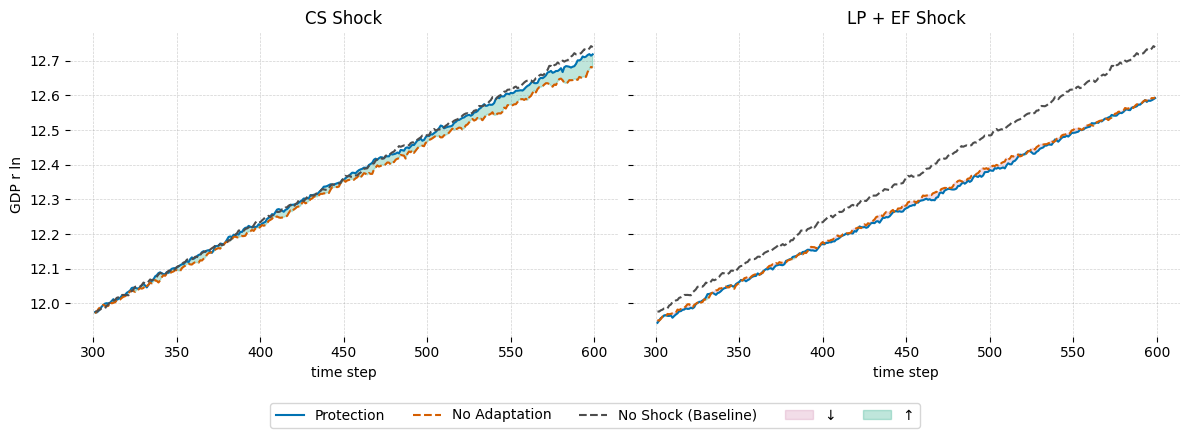

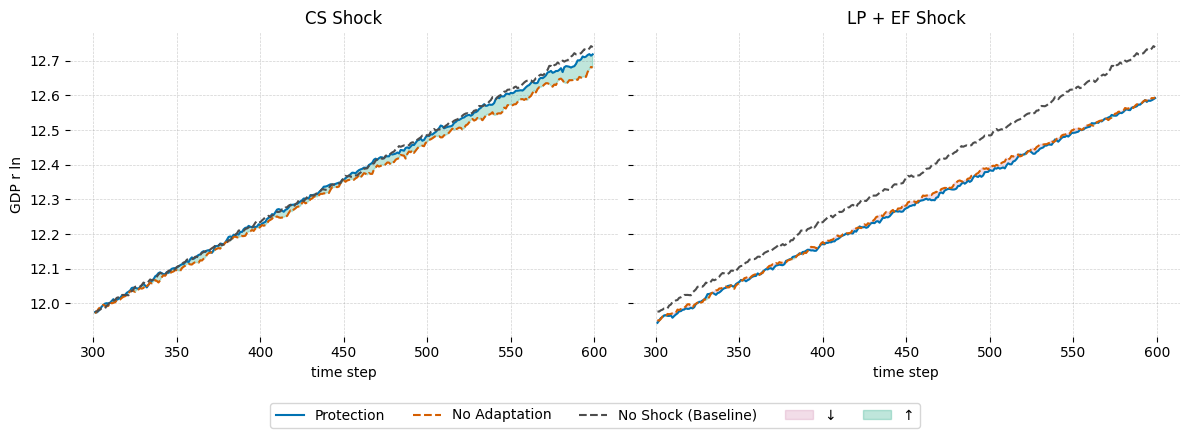

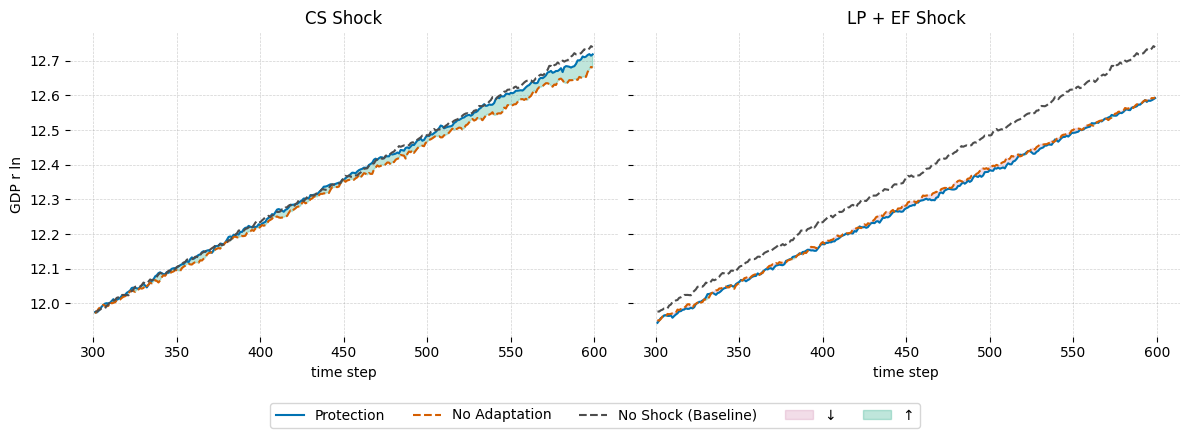

In [134]:
metric="GDP_r_ln"
metric_label = 'GDP r ln'
tmin = 300
tmax = 600
regions = [1, 2, 3]

for region in regions:

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True, dpi=100)
    for idx, n in enumerate(['2', '3']):
        s0 = (
            scenario_results['No Adaptation_1']
            .loc[lambda df: df['region'].isin(regions)]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s1 = (
            scenario_results[f'No Adaptation_{n}']
            .loc[lambda df: df['region'].isin(regions)]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s2 = (
            scenario_results[f'Protection_{n}']
            .loc[lambda df: df['region'].isin(regions)]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )

        s0.rename(columns={metric: 'No Shock'}, inplace=True)
        s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
        s2.rename(columns={metric: 'Protection'}, inplace=True)
        df = pd.merge(s1, s2, on='t')
        df = pd.merge(df, s0, on='t')
        df['t'] = df['t'].astype(int)
        df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

        ax = axes[idx]
        ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
        ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation")
        ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock (Baseline)")

        # Fill area where No Adaptation > Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
            interpolate=True, color="#CC79A7", alpha=0.25, label="↓" if idx == 0 else None
        )

        # Fill area where No Adaptation <= Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
            interpolate=True, color="#009E73", alpha=0.25, label="↑" if idx == 0 else None
        )


        ax.set_xlabel('time step')
        if n == '2':
            ax.set_title("CS Shock")
        else:
            ax.set_title("LP + EF Shock")

    # Only show legend on the first subplot
    # place legend outside plot area below x-axis label
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=5,
        frameon=True
    )
    axes[0].set_ylabel(metric_label)
    # turn off spineson both subplots
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    # add gridlinesto both subplots
    for ax in axes:
        ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

    plt.tight_layout()

    plt.show()

#### Avg. Annualized Real GDP Growth

In [26]:
scenario_names = ['scenario_1', 'scenario_2', ]
labels=['No Shock', 'CS - No Policy', ]

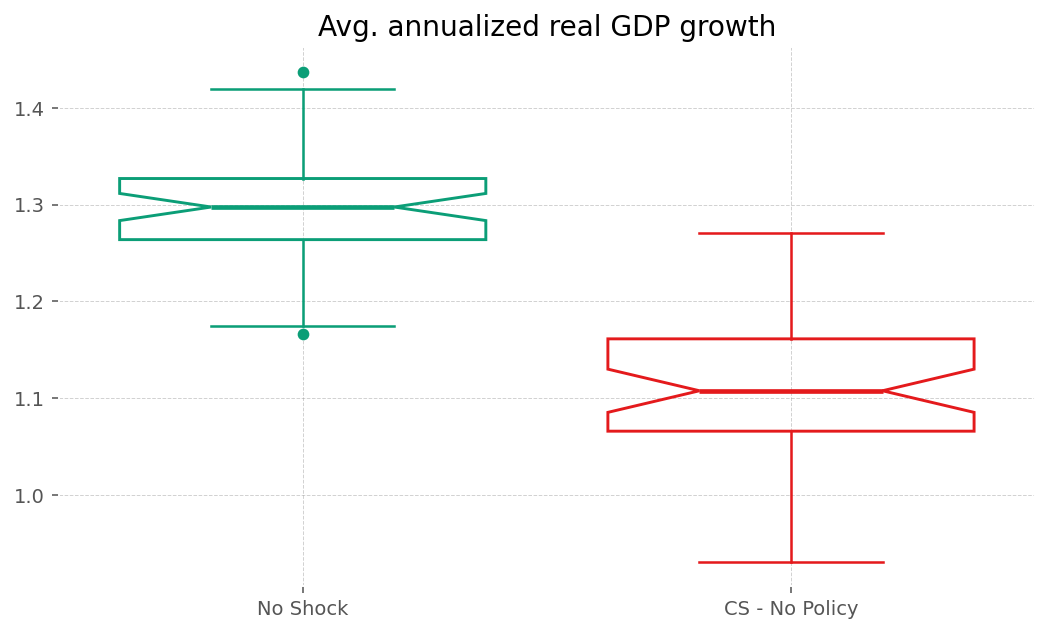

In [28]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()



plot_boxplots(
    metric=GDP_r_annualized_growth,
    scenario_names=scenario_names,
    labels=labels,
    colors=["#0B9E77", "#E41A1C",],
    figsize=(9, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path=OUTPUT / "GDP_r_annualized_growth.pdf"
)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_split_violin(metric, scenario_names, labels=None, title="Split Violin Plot", colors=None, y_label="Value", figsize=(7, 5.5), dpi=140, save_path=None, bw_method=0.2):
    """Plot split violin for paired scenarios (_1 vs _2, etc.) using KDE."""
    if labels is None:
        labels = [s for i, s in enumerate(scenario_names) if i % 2 == 0]
    if len(scenario_names) % 2 != 0:
        raise ValueError("scenario_names must have even length (pairs)")
    if len(labels) != len(scenario_names) // 2:
        raise ValueError("labels length must match number of pairs")
    if colors is None:
        palette = ["#0B9E77", "#E41A1C", "#56B4E9", "#FF7F00", "#984EA3", "#A65628"]
        color_list = [palette[i % len(palette)] for i in range(len(scenario_names))]
    elif isinstance(colors, dict):
        color_list = [colors[name] for name in scenario_names]
    else:
        if len(colors) != len(scenario_names):
            raise ValueError("colors length must match scenario_names length")
        color_list = list(colors)
    data = []
    for name in scenario_names:
        values = metric[name]
        if hasattr(values, "dropna"):
            values = values.dropna()
        data.append(np.asarray(values, dtype=float))
    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    for i in range(0, len(scenario_names), 2):
        left = data[i]
        right = data[i+1]
        pos = i // 2
        # KDE for each side
        for side, vals, color, sign in [("left", left, color_list[i], -1), ("right", right, color_list[i+1], 1)]:
            if len(vals) < 2:
                continue
            kde = gaussian_kde(vals, bw_method=bw_method)
            y = np.linspace(np.min(vals), np.max(vals), 200)
            v = kde(y)
            v = v / v.max() * 0.4  # scale width
            ax.fill_betweenx(y, pos + sign * v, pos, color=color, alpha=0.7, linewidth=0)
            # Median line
            ax.plot([pos, pos + sign * 0.4], [np.median(vals)]*2, color=color, lw=2.4)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.set_facecolor("#ffffff")
    ax.grid(True, axis="both", alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='both')
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()

# Example usage (uncomment to run):
# plot_split_violin(metric=GDP_r_annualized_growth, scenario_names=scenario_names, labels=labels, title="Split Violin Plot", colors=None, y_label="Value")

### Crisis Likelihood

In [33]:
scenario_results.keys()

dict_keys(['scenario_1', 'scenario_2'])

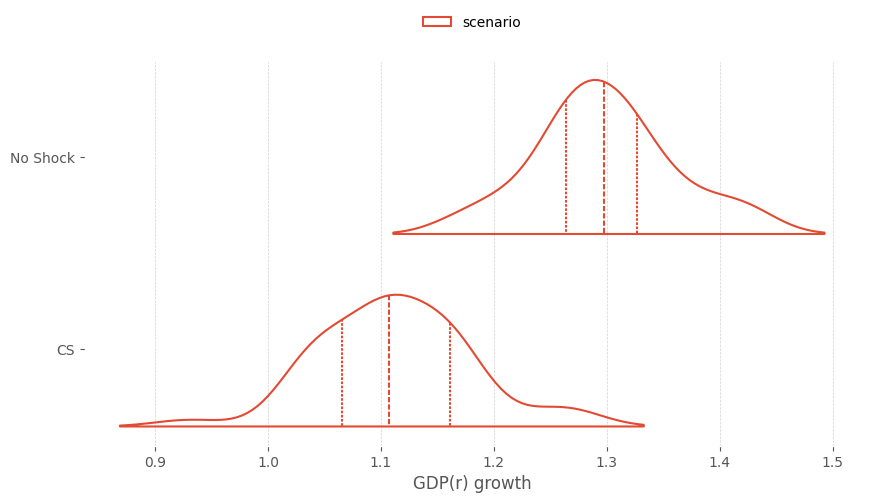

In [34]:
plot_split_violinplot(
    scenario_results,
    metric='GDP_r_growth',
    metric_label='GDP(r) growth',
    region='macro',
    tmin=200,
    # palette={"scenario_1": "#00000082", "scenario_2": "#0B9E77"}
)

AttributeError: 'NoneType' object has no attribute 'keys'

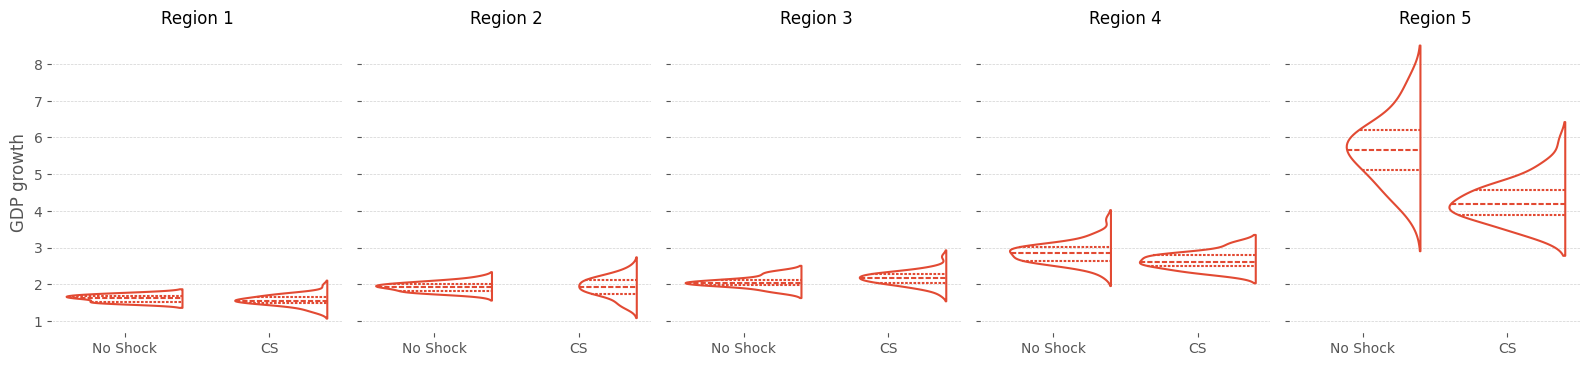

In [36]:
plot_regional_split_violin(
    metric="GDP_r_growth",
    metric_label="GDP growth",
    tmin=200,
    scenario_mapper={
        1: 'No Shock',
        2: 'CS',
        3: 'LP+EF'
    },
#     palette={
#         "No Adaptation": "#00000082",
#         "Protection": "#0B9E77"
#     }
)

### Deficit

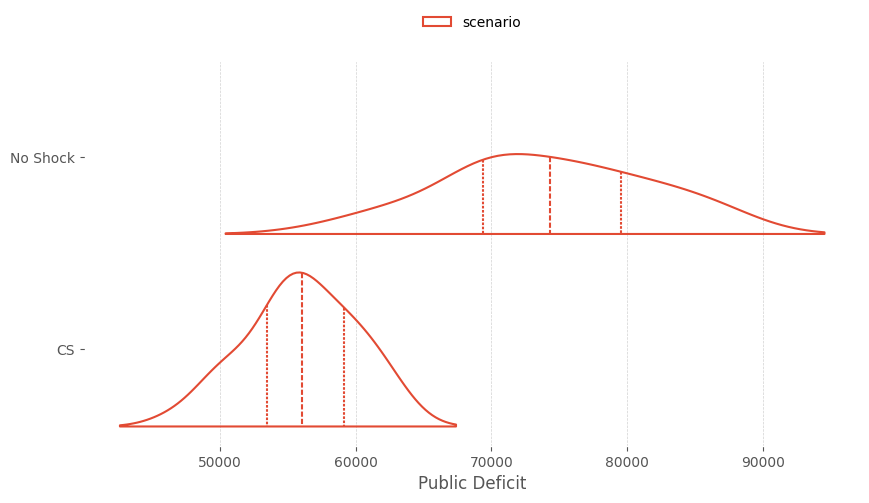

In [37]:
plot_split_violinplot(
    scenario_results,
    metric='Deficit',
    metric_label='Public Deficit',
    region='macro',
    tmin=200,
    # palette={"No Adaptation": "#00000082", "Protection": "#0B9E77"}
)

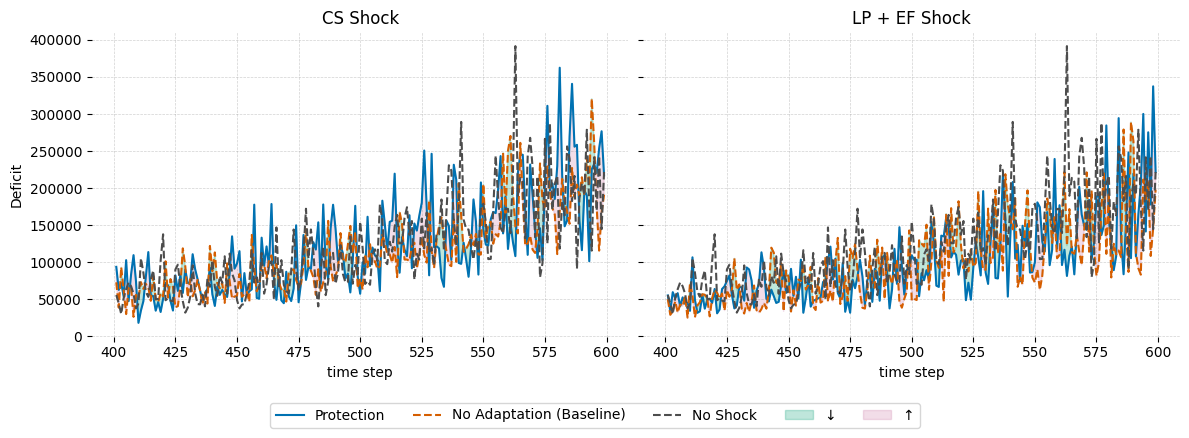

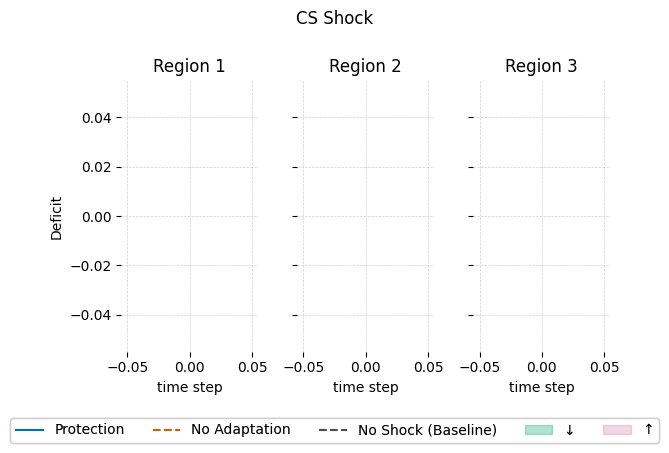

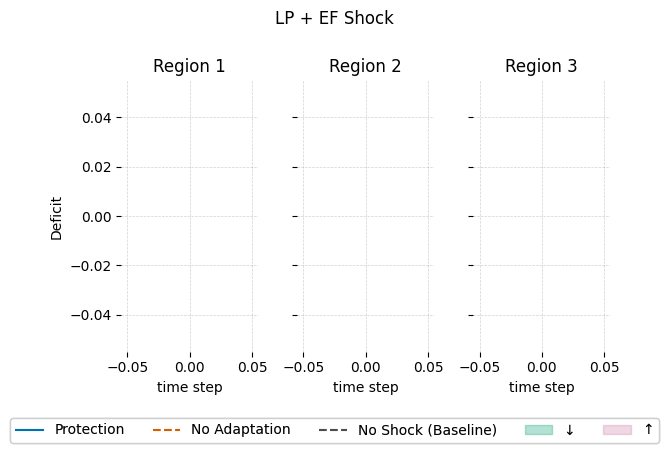

In [177]:
metric="Deficit"
metric_label = 'Deficit'
tmin = 400
tmax = 600
regions = ['macro']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True, dpi=100)
for idx, n in enumerate(['2', '3']):
    s0 = (
        scenario_results['No Adaptation_1']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s1 = (
        scenario_results[f'No Adaptation_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s2 = (
        scenario_results[f'Protection_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )

    s0.rename(columns={metric: 'No Shock'}, inplace=True)
    s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
    s2.rename(columns={metric: 'Protection'}, inplace=True)
    df = pd.merge(s1, s2, on='t')
    df = pd.merge(df, s0, on='t')
    df['t'] = df['t'].astype(int)
    df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

    ax = axes[idx]
    ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
    ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation (Baseline)")
    ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock")

    # Fill area where No Adaptation > Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
        interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
    )

    # Fill area where No Adaptation <= Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
        interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
    )


    ax.set_xlabel('time step')
    if n == '2':
        ax.set_title("CS Shock")
    else:
        ax.set_title("LP + EF Shock")

# Only show legend on the first subplot
# place legend outside plot area below x-axis label
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    frameon=True
)
axes[0].set_ylabel(metric_label)
# turn off spineson both subplots
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

# add gridlinesto both subplots
for ax in axes:
    ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

plt.tight_layout()
plt.savefig(OUTPUT / f"{metric}_area_diff.pdf", bbox_inches='tight', dpi=300)
plt.show()


# metric="GDP_r_volatility"
# metric_label = 'GDP volatility'
# tmin = 300
# tmax = 600
for n in ['2', '3']:
    regions = [1, 2, 3]
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 4), sharey=True, dpi=100)
    for idx, region in enumerate(regions):

        s0 = (
            scenario_results['No Adaptation_1']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s1 = (
            scenario_results[f'No Adaptation_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s2 = (
            scenario_results[f'Protection_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )

        s0.rename(columns={metric: 'No Shock'}, inplace=True)
        s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
        s2.rename(columns={metric: 'Protection'}, inplace=True)
        df = pd.merge(s1, s2, on='t')
        df = pd.merge(df, s0, on='t')
        df['t'] = df['t'].astype(int)
        df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

        ax = axes[idx]
        ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
        ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation")
        ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock (Baseline)")

        # Fill area where No Adaptation > Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
            interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
        )

        # Fill area where No Adaptation <= Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
            interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
        )


        ax.set_xlabel('time step')

        ax.set_title(f"Region {region}")


        # Only show legend on the first subplot
        # place legend outside plot area below x-axis label
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.1),
        ncol=5,
        frameon=True
    )
    axes[0].set_ylabel(metric_label)
    # turn off spineson both subplots
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    # add gridlinesto both subplots
    for ax in axes:
        ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

    # set figure title based on shock type
    if n == '2':
        fig.suptitle("CS Shock", y=1)
    elif n == '3':
        fig.suptitle("LP + EF Shock", y=1)

    plt.tight_layout()
    plt.savefig(OUTPUT / f"{metric}_area_diff_region_scenario{n}.pdf", bbox_inches='tight', dpi=300)
    plt.show()

### GDP volatility

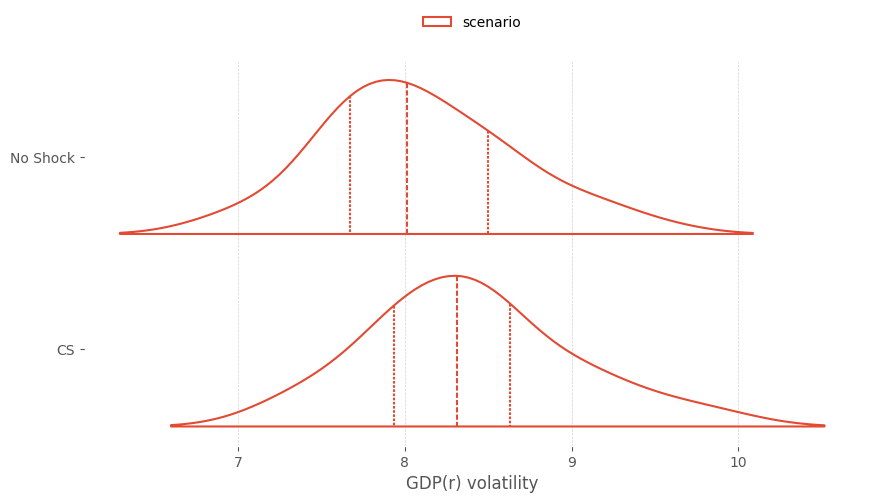

In [38]:
plot_split_violinplot(
    scenario_results,
    metric='GDP_r_volatility',
    metric_label='GDP(r) volatility',
    region='macro',
    tmin=200,
    # palette={"No Adaptation": "#00000082", "Protection": "#0B9E77"}
)

AttributeError: 'NoneType' object has no attribute 'keys'

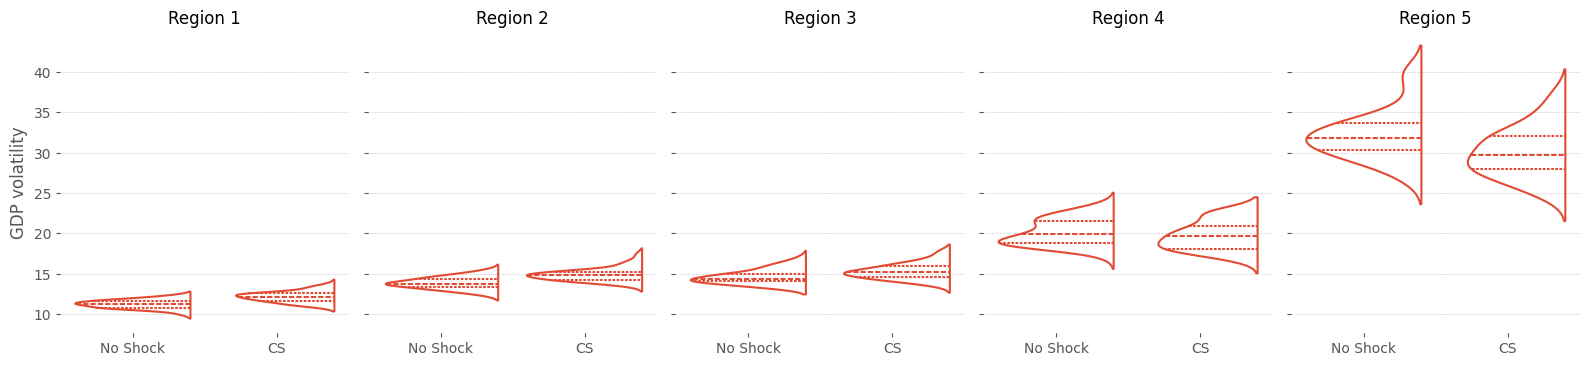

In [39]:
plot_regional_split_violin(
    metric="GDP_r_volatility",
    metric_label="GDP volatility",
    tmin=200,
    scenario_mapper={
        1: 'No Shock',
        2: 'CS',
        3: 'LP+EF'
    },
    # palette={
    #     "No Adaptation": "#00000082",
    #     "Protection": "#0B9E77"
    # }
)

In [116]:
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="GDP_r_volatility",
    metric_label='GDP volatility',
    snap_ts=np.arange(200, 620, 20),
    title='GDP volatility',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "GDP_r_volatility.pdf",
    # ymin=12.8, ymax=14
)

fig1

Resorting to unclean kill browser.
Resorting to unclean kill browser.


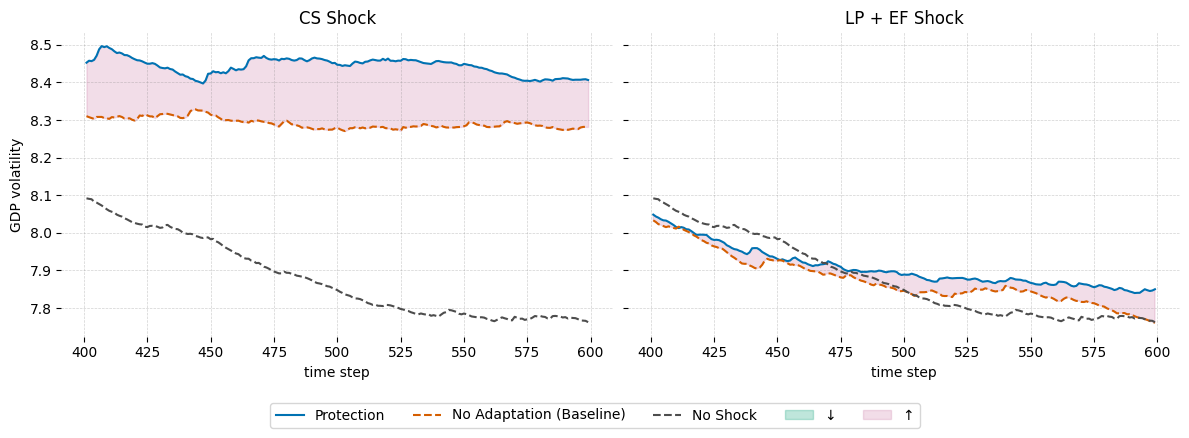

In [178]:
metric="GDP_r_volatility"
metric_label = 'GDP volatility'
tmin = 400
tmax = 600
regions = ['macro']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True, dpi=100)
for idx, n in enumerate(['2', '3']):
    s0 = (
        scenario_results['No Adaptation_1']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s1 = (
        scenario_results[f'No Adaptation_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s2 = (
        scenario_results[f'Protection_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )

    s0.rename(columns={metric: 'No Shock'}, inplace=True)
    s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
    s2.rename(columns={metric: 'Protection'}, inplace=True)
    df = pd.merge(s1, s2, on='t')
    df = pd.merge(df, s0, on='t')
    df['t'] = df['t'].astype(int)
    df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

    ax = axes[idx]
    ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
    ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation (Baseline)")
    ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock")

    # Fill area where No Adaptation > Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
        interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
    )

    # Fill area where No Adaptation <= Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
        interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
    )


    ax.set_xlabel('time step')
    if n == '2':
        ax.set_title("CS Shock")
    else:
        ax.set_title("LP + EF Shock")

# Only show legend on the first subplot
# place legend outside plot area below x-axis label
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    frameon=True
)
axes[0].set_ylabel(metric_label)
# turn off spineson both subplots
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

# add gridlinesto both subplots
for ax in axes:
    ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

plt.tight_layout()
plt.savefig(OUTPUT / f"{metric}_area_diff.pdf", bbox_inches='tight', dpi=300)
plt.show()

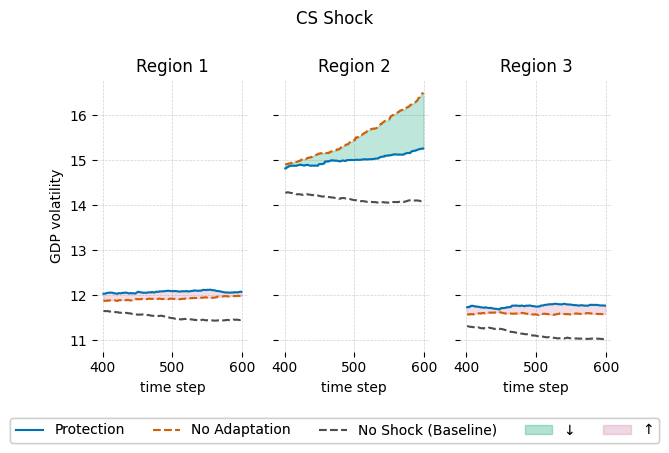

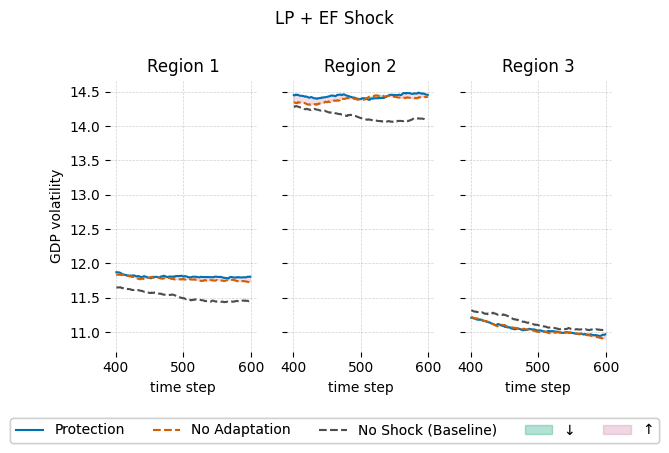

In [179]:
# metric="GDP_r_volatility"
# metric_label = 'GDP volatility'
# tmin = 300
# tmax = 600
for n in ['2', '3']:
    regions = [1, 2, 3]
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 4), sharey=True, dpi=100)
    for idx, region in enumerate(regions):

        s0 = (
            scenario_results['No Adaptation_1']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s1 = (
            scenario_results[f'No Adaptation_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s2 = (
            scenario_results[f'Protection_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )

        s0.rename(columns={metric: 'No Shock'}, inplace=True)
        s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
        s2.rename(columns={metric: 'Protection'}, inplace=True)
        df = pd.merge(s1, s2, on='t')
        df = pd.merge(df, s0, on='t')
        df['t'] = df['t'].astype(int)
        df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

        ax = axes[idx]
        ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
        ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation")
        ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock (Baseline)")

        # Fill area where No Adaptation > Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
            interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
        )

        # Fill area where No Adaptation <= Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
            interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
        )


        ax.set_xlabel('time step')

        ax.set_title(f"Region {region}")


        # Only show legend on the first subplot
        # place legend outside plot area below x-axis label
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.1),
        ncol=5,
        frameon=True
    )
    axes[0].set_ylabel(metric_label)
    # turn off spineson both subplots
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    # add gridlinesto both subplots
    for ax in axes:
        ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

    # set figure title based on shock type
    if n == '2':
        fig.suptitle("CS Shock", y=1)
    elif n == '3':
        fig.suptitle("LP + EF Shock", y=1)

    plt.tight_layout()
    plt.savefig(OUTPUT / f"{metric}_area_diff_region_scenario{n}.pdf", bbox_inches='tight', dpi=300)
    plt.show()

### GDP Growth

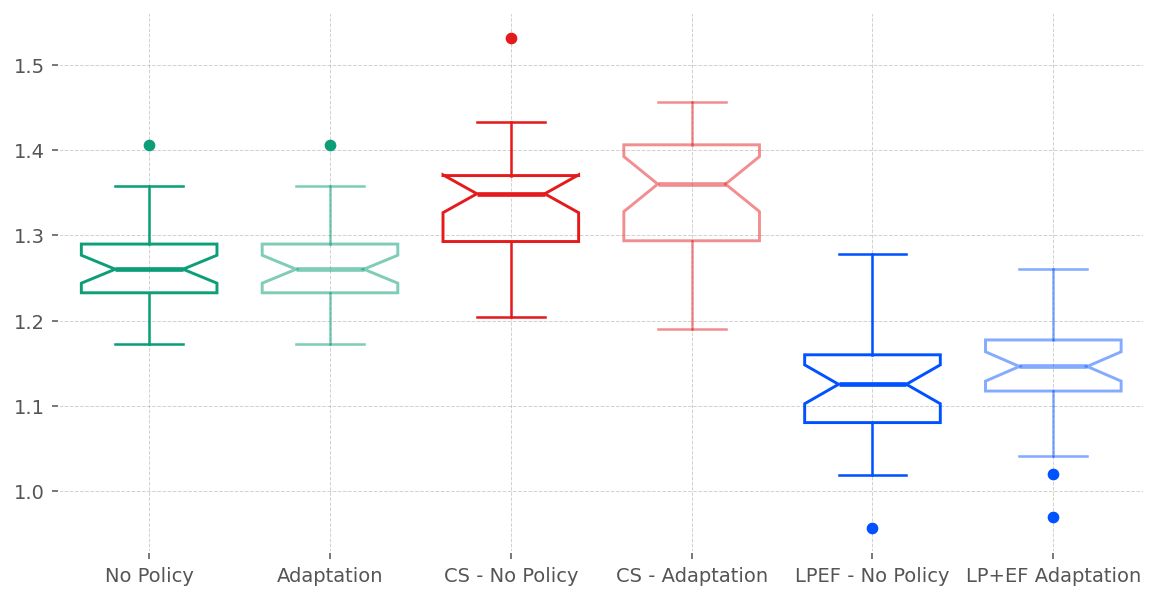

In [18]:
metric = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    metric[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()
        

plot_boxplots(
    metric=metric,
    scenario_names=scenario_names,
    labels=labels,
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="",
    y_label='',
    save_path=OUTPUT/"GDP_r_growth.pdf",
)

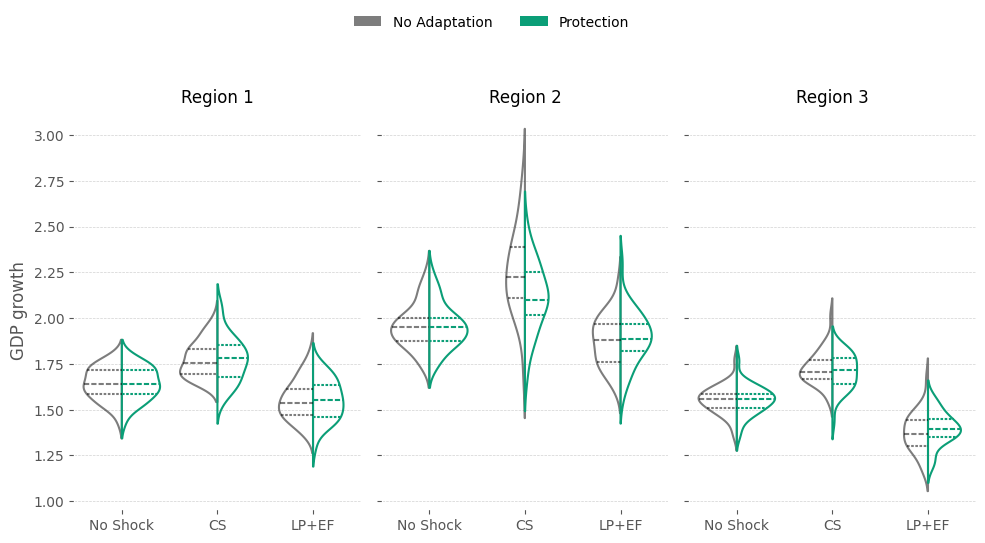

In [38]:
plot_regional_split_violin(
    metric="GDP_r_growth",
    metric_label="GDP growth",
    tmin=200,
    scenario_mapper={
        1: 'No Shock',
        2: 'CS',
        3: 'LP+EF'
    },
    palette={
        "No Adaptation": "#00000082",
        "Protection": "#0B9E77"
    }
)

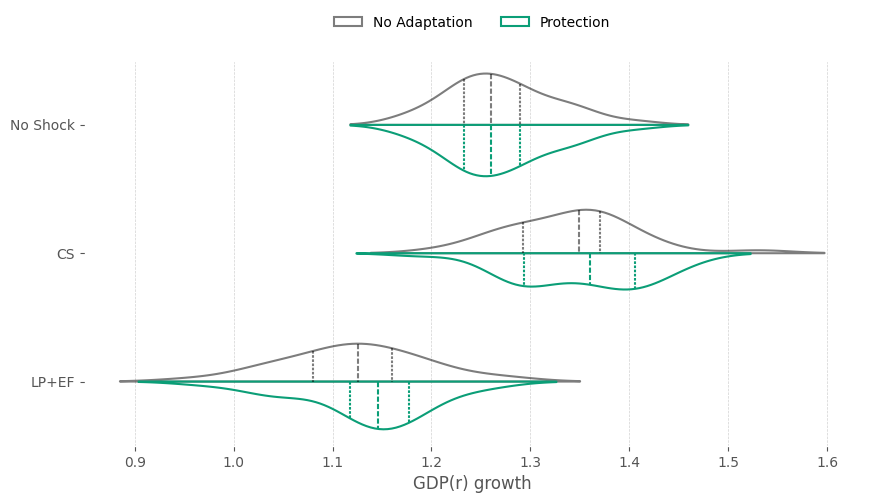

In [36]:
plot_split_violinplot(
    scenario_results,
    metric='GDP_r_growth',
    metric_label='GDP(r) growth',
    region='macro',
    tmin=200,
    palette={"No Adaptation": "#00000082", "Protection": "#0B9E77"}
)

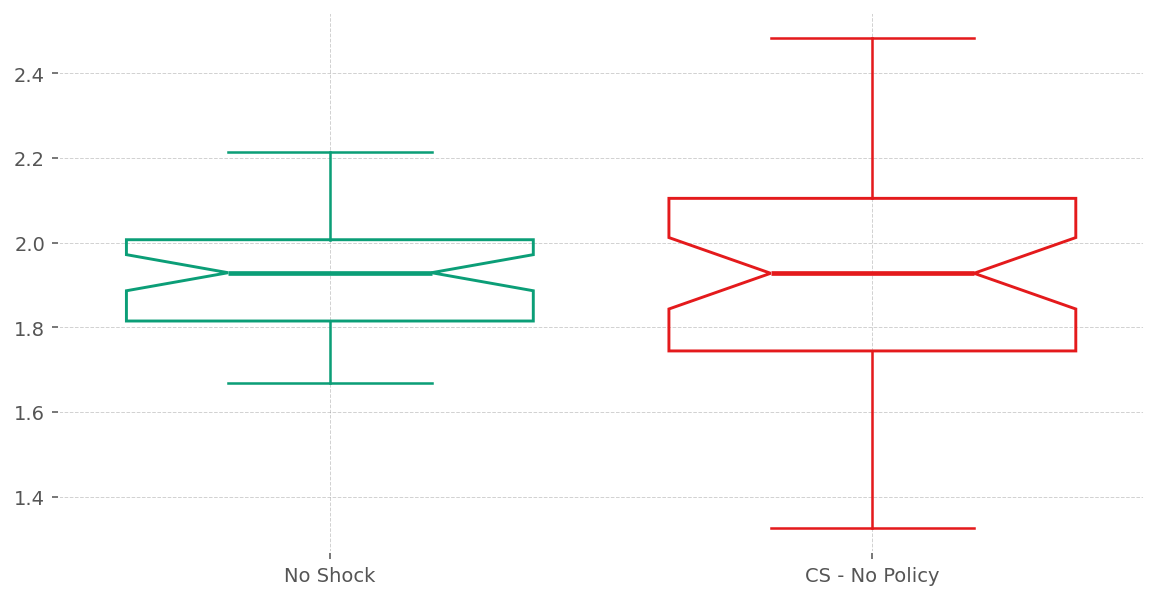

In [40]:
metric = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']==2].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    metric[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()
        

plot_boxplots(
    metric=metric,
    scenario_names=scenario_names,
    labels=labels,
    # colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="",
    y_label='',
    save_path=OUTPUT/"GDP_r_growth.pdf",
)

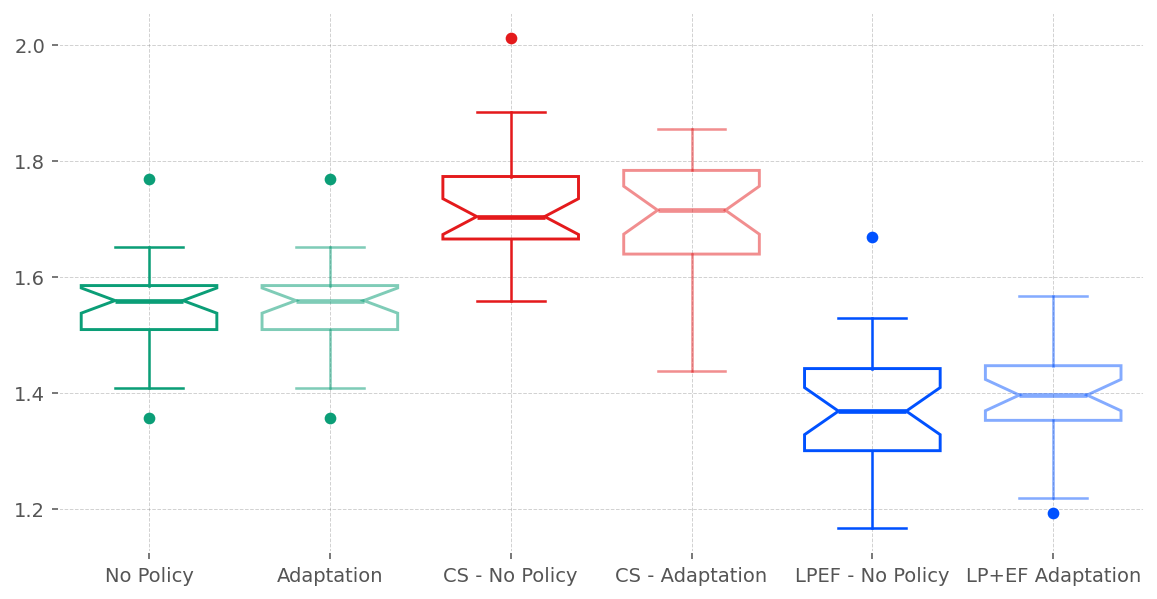

In [24]:
metric = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']==3].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    metric[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()
        

plot_boxplots(
    metric=metric,
    scenario_names=scenario_names,
    labels=labels,
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="",
    y_label='',
    save_path=OUTPUT/"GDP_r_growth.pdf",
)

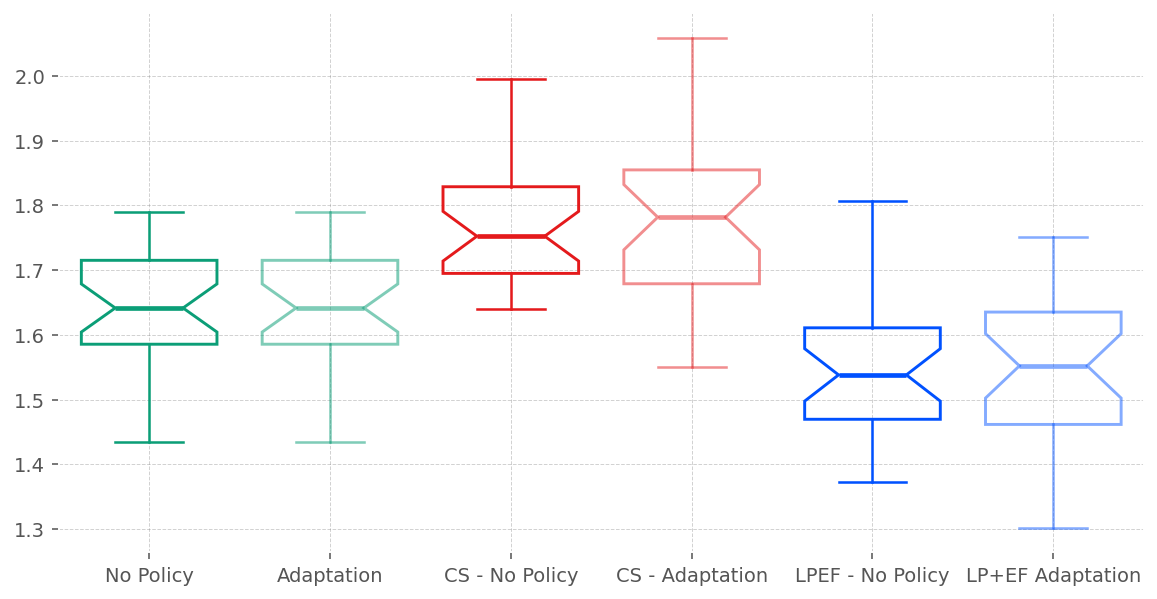

In [25]:
metric = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']==1].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    metric[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()
        

plot_boxplots(
    metric=metric,
    scenario_names=scenario_names,
    labels=labels,
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="",
    y_label='',
    save_path=OUTPUT/"GDP_r_growth.pdf",
)

In [26]:

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="GDP_r_growth",
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title='Real GDP Growth',
    line_type='lines',
    ncol_legend=3,
    ymin=-15,
    ymax=20,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "GDP_r_growth_line.pdf",
)
fig1


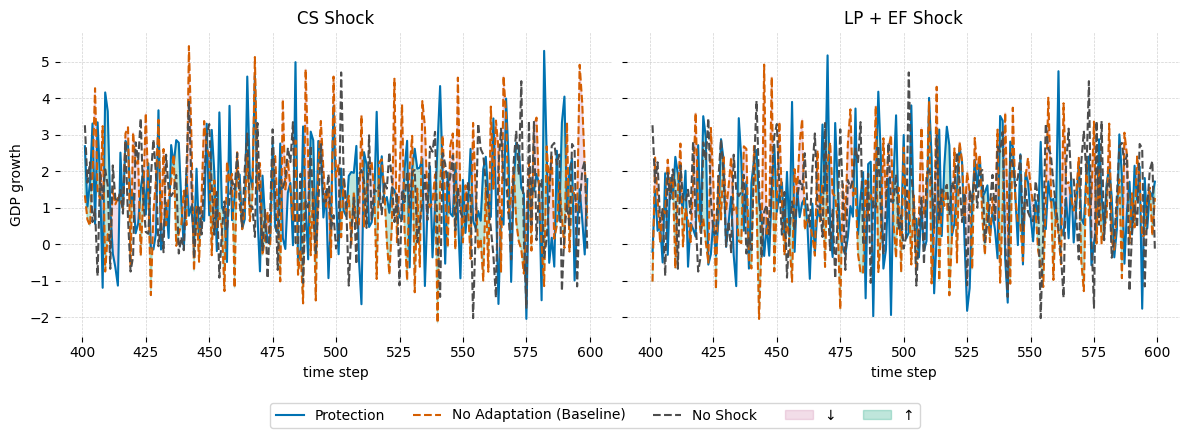

In [183]:
metric="GDP_r_growth"
metric_label = 'GDP growth'
tmin = 400
tmax = 600
regions = ['macro']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True, dpi=100)
for idx, n in enumerate(['2', '3']):
    s0 = (
        scenario_results['No Adaptation_1']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s1 = (
        scenario_results[f'No Adaptation_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s2 = (
        scenario_results[f'Protection_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )

    s0.rename(columns={metric: 'No Shock'}, inplace=True)
    s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
    s2.rename(columns={metric: 'Protection'}, inplace=True)
    df = pd.merge(s1, s2, on='t')
    df = pd.merge(df, s0, on='t')
    df['t'] = df['t'].astype(int)
    df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

    ax = axes[idx]
    ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
    ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation (Baseline)")
    ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock")

    # Fill area where No Adaptation > Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
        interpolate=True, color="#CC79A7", alpha=0.25, label="↓" if idx == 0 else None
    )

    # Fill area where No Adaptation <= Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
        interpolate=True, color="#009E73", alpha=0.25, label="↑" if idx == 0 else None
    )


    ax.set_xlabel('time step')
    if n == '2':
        ax.set_title("CS Shock")
    else:
        ax.set_title("LP + EF Shock")

# Only show legend on the first subplot
# place legend outside plot area below x-axis label
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    frameon=True
)
axes[0].set_ylabel(metric_label)
# turn off spineson both subplots
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

# add gridlinesto both subplots
for ax in axes:
    ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

plt.tight_layout()
plt.savefig(OUTPUT / f"{metric}_area_diff.pdf", bbox_inches='tight', dpi=300)
plt.show()

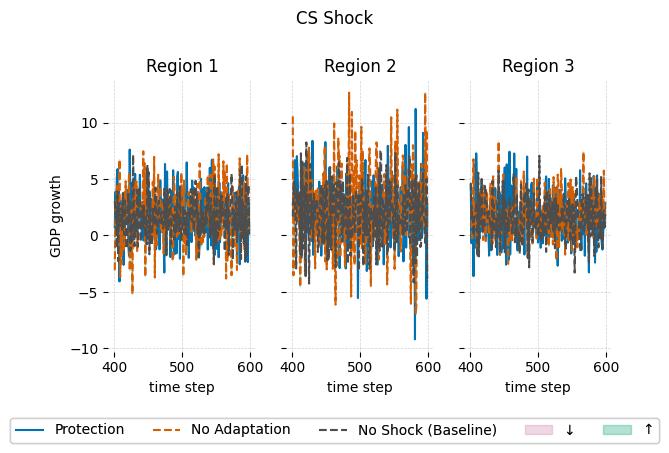

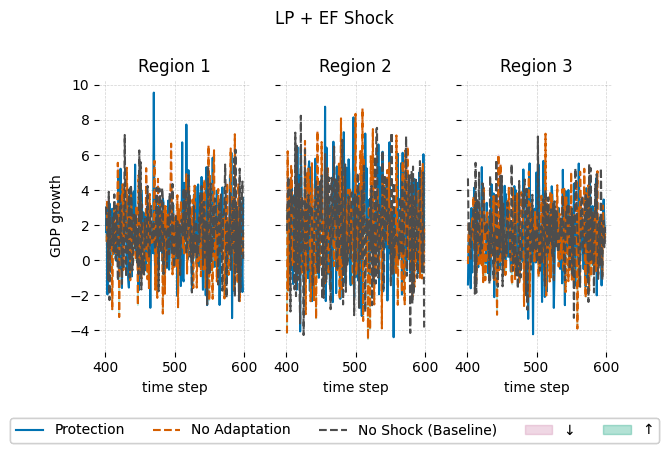

In [182]:
# metric="GDP_r_volatility"
# metric_label = 'GDP volatility'
# tmin = 300
# tmax = 600
for n in ['2', '3']:
    regions = [1, 2, 3]
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 4), sharey=True, dpi=100)
    for idx, region in enumerate(regions):

        s0 = (
            scenario_results['No Adaptation_1']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s1 = (
            scenario_results[f'No Adaptation_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s2 = (
            scenario_results[f'Protection_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )

        s0.rename(columns={metric: 'No Shock'}, inplace=True)
        s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
        s2.rename(columns={metric: 'Protection'}, inplace=True)
        df = pd.merge(s1, s2, on='t')
        df = pd.merge(df, s0, on='t')
        df['t'] = df['t'].astype(int)
        df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

        ax = axes[idx]
        ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
        ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation")
        ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock (Baseline)")

        # Fill area where No Adaptation > Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
            interpolate=True, color="#CC79A7", alpha=0.25, label="↓" if idx == 0 else None
        )

        # Fill area where No Adaptation <= Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
            interpolate=True, color="#009E73", alpha=0.25, label="↑" if idx == 0 else None
        )


        ax.set_xlabel('time step')

        ax.set_title(f"Region {region}")


        # Only show legend on the first subplot
        # place legend outside plot area below x-axis label
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.1),
        ncol=5,
        frameon=True
    )
    axes[0].set_ylabel(metric_label)
    # turn off spineson both subplots
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    # add gridlinesto both subplots
    for ax in axes:
        ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

    # set figure title based on shock type
    if n == '2':
        fig.suptitle("CS Shock", y=1)
    elif n == '3':
        fig.suptitle("LP + EF Shock", y=1)

    plt.tight_layout()
    plt.savefig(OUTPUT / f"{metric}_area_diff_region_scenario{n}.pdf", bbox_inches='tight', dpi=300)
    plt.show()

### Bad debt as % of nominal GDP

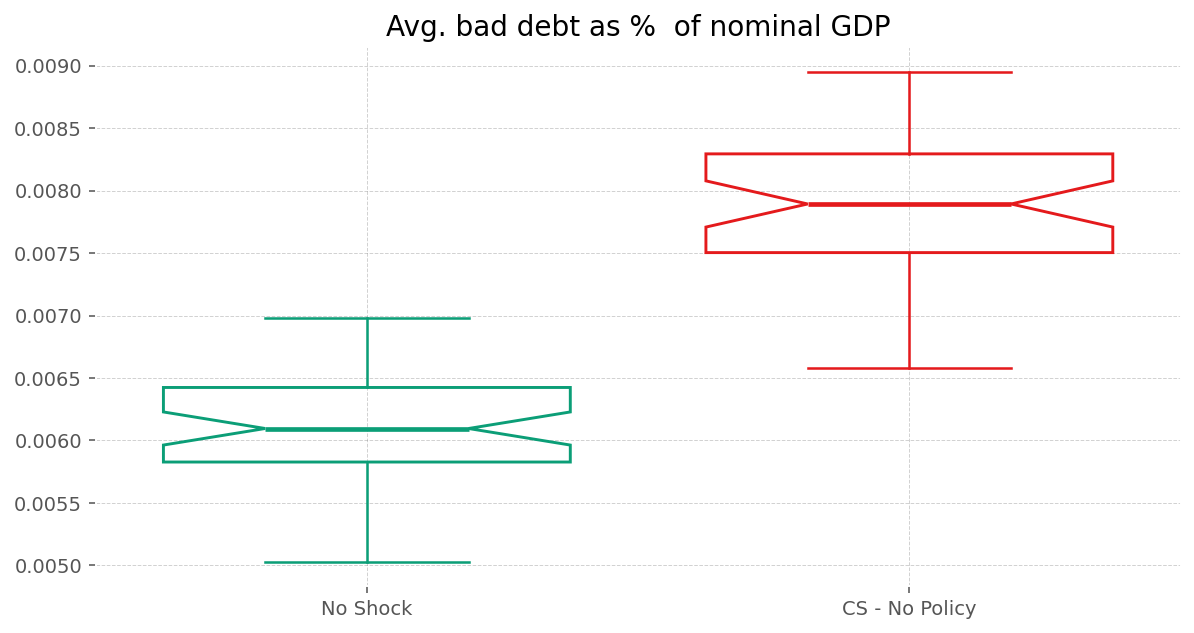

In [41]:
bad_debt_b_over_GDPn = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    bad_debt_b_over_GDPn[scenario] = temp_df.groupby(['run'])['baddebt_b_over_GDP'].mean()
        

plot_boxplots(
    metric=bad_debt_b_over_GDPn,
    scenario_names=scenario_names,
    labels=labels,
    # colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. bad debt as %  of nominal GDP",
    y_label='',
    save_path=OUTPUT/"baddebt_b_over_GDP.pdf",
)

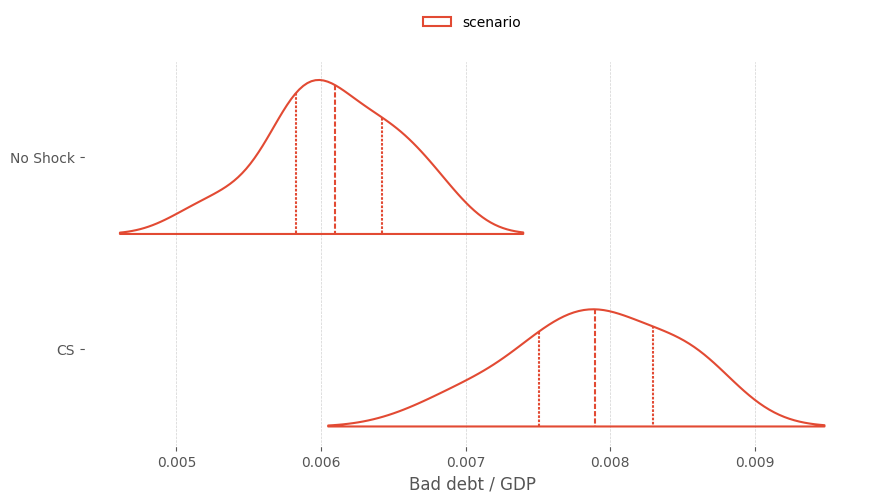

In [42]:
plot_split_violinplot(
    scenario_results,
    metric='baddebt_b_over_GDP',
    metric_label='Bad debt / GDP',
    region='macro',
    tmin=200,
    # palette={"No Adaptation": "#00000082", "Protection": "#0B9E77"}
)

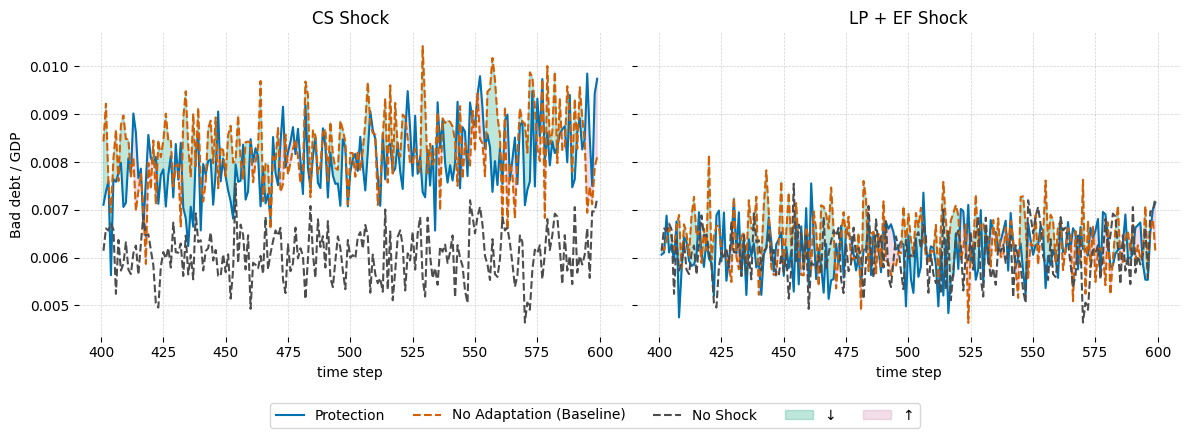

In [186]:
metric="baddebt_b_over_GDP"
metric_label = 'Bad debt / GDP'
tmin = 400
tmax = 600
regions = ['macro']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True, dpi=100)
for idx, n in enumerate(['2', '3']):
    s0 = (
        scenario_results['No Adaptation_1']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s1 = (
        scenario_results[f'No Adaptation_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s2 = (
        scenario_results[f'Protection_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )

    s0.rename(columns={metric: 'No Shock'}, inplace=True)
    s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
    s2.rename(columns={metric: 'Protection'}, inplace=True)
    df = pd.merge(s1, s2, on='t')
    df = pd.merge(df, s0, on='t')
    df['t'] = df['t'].astype(int)
    df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

    ax = axes[idx]
    ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
    ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation (Baseline)")
    ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock")

    # Fill area where No Adaptation > Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
        interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
    )

    # Fill area where No Adaptation <= Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
        interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
    )


    ax.set_xlabel('time step')
    if n == '2':
        ax.set_title("CS Shock")
    else:
        ax.set_title("LP + EF Shock")

# Only show legend on the first subplot
# place legend outside plot area below x-axis label
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    frameon=True
)
axes[0].set_ylabel(metric_label)
# turn off spineson both subplots
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

# add gridlinesto both subplots
for ax in axes:
    ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

plt.tight_layout()
plt.savefig(OUTPUT / f"{metric}_area_diff.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [40]:

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="baddebt_b_over_GDP",
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title='baddebt_b_over_GDP',
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=0.015,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "baddebt_line.pdf",
)
fig1

### Number of C-Firms failure

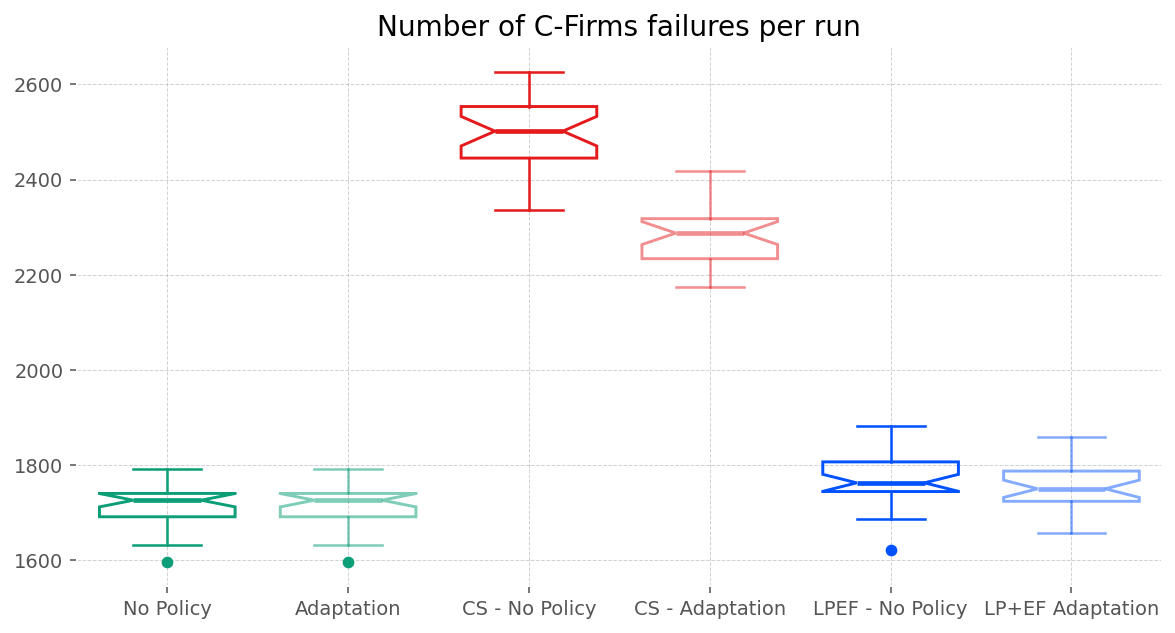

In [41]:
Exiting_CFirms = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    Exiting_CFirms[scenario] = temp_df.groupby(['run'])['Exiting_C-Firms'].sum()
        

plot_boxplots(
    metric=Exiting_CFirms,
    scenario_names=scenario_names,
    labels=labels,
    colors=["#0B9E77","#0B9E7786", 
            "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"
            ],
    figsize=(10, 5),
    title="Number of C-Firms failures per run",
    y_label='',
    save_path=OUTPUT / "Exiting_C-Firms.pdf",
)

In [42]:

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric='Exiting_C-Firms',
    metric_label='Avg. Cfirms exiting per run',
    snap_ts=np.arange(200, 620, 20),
    title='Exiting_C-Firms',
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=12,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "Exiting_C-Firms_line.pdf",
)
fig1

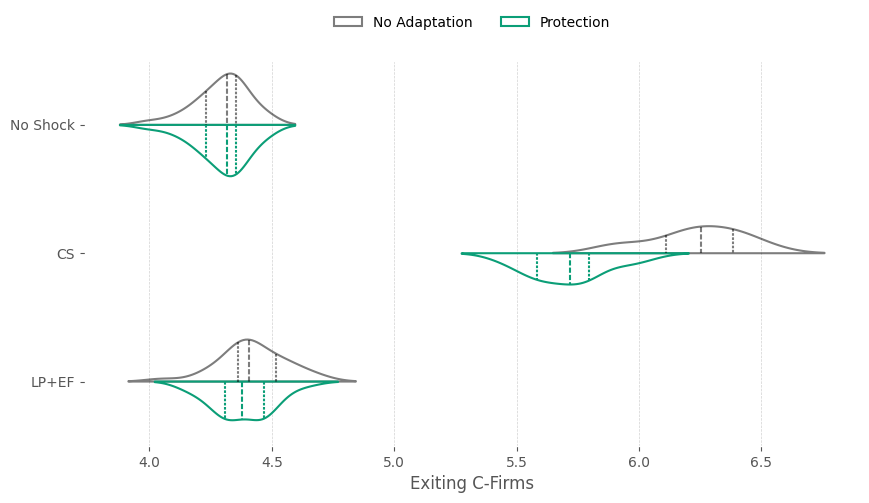

In [43]:
plot_split_violinplot(
    scenario_results,
    metric='Exiting_C-Firms',
    metric_label='Exiting C-Firms',
    region='macro',
    tmin=200,
    palette={"No Adaptation": "#00000082", "Protection": "#0B9E77"}
)

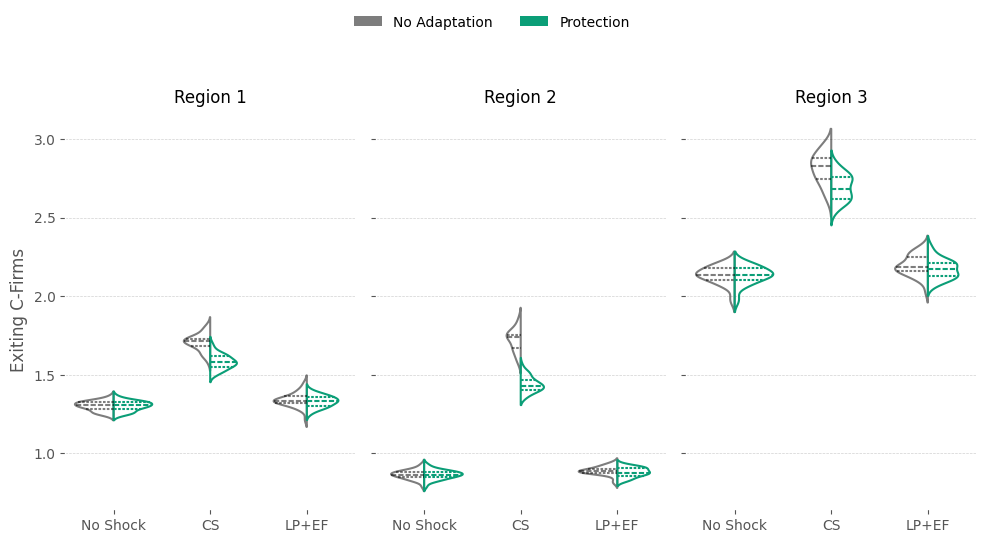

In [57]:
plot_regional_split_violin(
    metric="Exiting_C-Firms",
    metric_label="Exiting C-Firms",
    tmin=200,
    scenario_mapper={
        1: 'No Shock',
        2: 'CS',
        3: 'LP+EF'
    },
    palette={
        "No Adaptation": "#00000082",
        "Protection": "#0B9E77"
    }
)

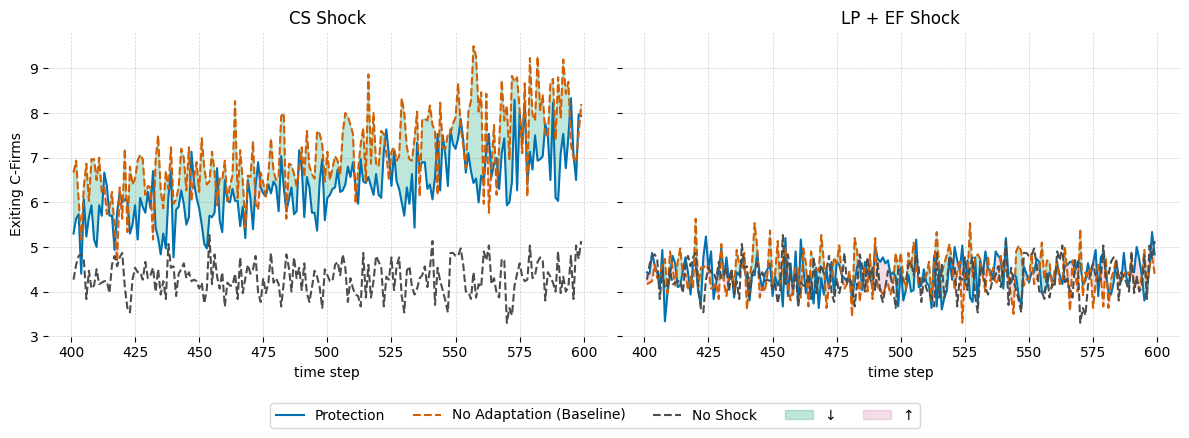

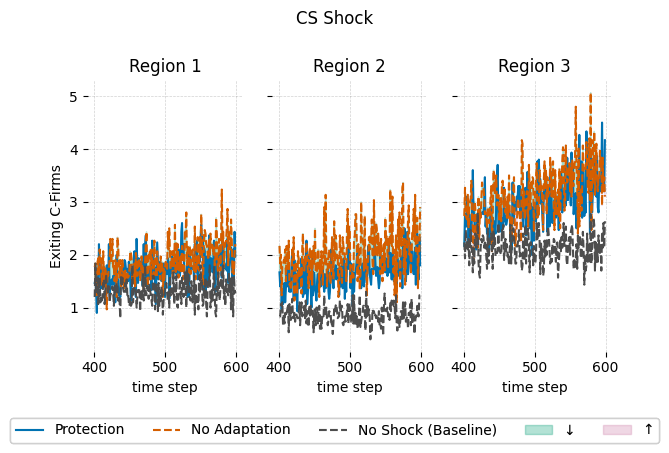

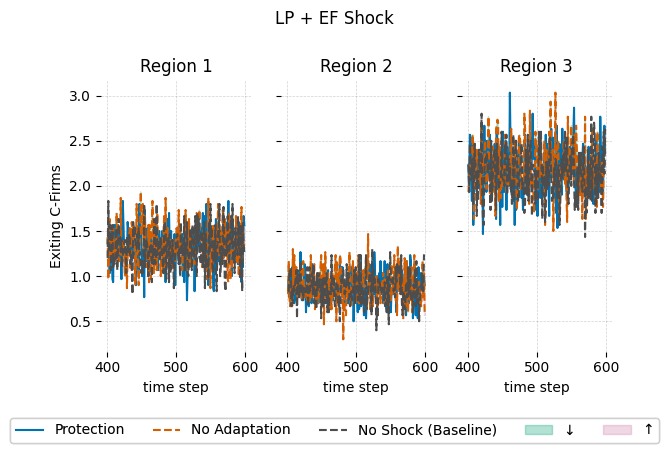

In [188]:
metric="Exiting_C-Firms"
metric_label = 'Exiting C-Firms'
tmin = 400
tmax = 600
regions = ['macro']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True, dpi=100)
for idx, n in enumerate(['2', '3']):
    s0 = (
        scenario_results['No Adaptation_1']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s1 = (
        scenario_results[f'No Adaptation_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s2 = (
        scenario_results[f'Protection_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )

    s0.rename(columns={metric: 'No Shock'}, inplace=True)
    s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
    s2.rename(columns={metric: 'Protection'}, inplace=True)
    df = pd.merge(s1, s2, on='t')
    df = pd.merge(df, s0, on='t')
    df['t'] = df['t'].astype(int)
    df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

    ax = axes[idx]
    ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
    ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation (Baseline)")
    ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock")

    # Fill area where No Adaptation > Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
        interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
    )

    # Fill area where No Adaptation <= Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
        interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
    )


    ax.set_xlabel('time step')
    if n == '2':
        ax.set_title("CS Shock")
    else:
        ax.set_title("LP + EF Shock")

# Only show legend on the first subplot
# place legend outside plot area below x-axis label
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    frameon=True
)
axes[0].set_ylabel(metric_label)
# turn off spineson both subplots
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

# add gridlinesto both subplots
for ax in axes:
    ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

plt.tight_layout()
plt.savefig(OUTPUT / f"{metric}_area_diff.pdf", bbox_inches='tight', dpi=300)
plt.show()


# metric="GDP_r_volatility"
# metric_label = 'GDP volatility'
# tmin = 300
# tmax = 600
for n in ['2', '3']:
    regions = [1, 2, 3]
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 4), sharey=True, dpi=100)
    for idx, region in enumerate(regions):

        s0 = (
            scenario_results['No Adaptation_1']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s1 = (
            scenario_results[f'No Adaptation_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s2 = (
            scenario_results[f'Protection_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )

        s0.rename(columns={metric: 'No Shock'}, inplace=True)
        s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
        s2.rename(columns={metric: 'Protection'}, inplace=True)
        df = pd.merge(s1, s2, on='t')
        df = pd.merge(df, s0, on='t')
        df['t'] = df['t'].astype(int)
        df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

        ax = axes[idx]
        ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
        ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation")
        ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock (Baseline)")

        # Fill area where No Adaptation > Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
            interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
        )

        # Fill area where No Adaptation <= Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
            interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
        )


        ax.set_xlabel('time step')

        ax.set_title(f"Region {region}")


        # Only show legend on the first subplot
        # place legend outside plot area below x-axis label
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.1),
        ncol=5,
        frameon=True
    )
    axes[0].set_ylabel(metric_label)
    # turn off spineson both subplots
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    # add gridlinesto both subplots
    for ax in axes:
        ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

    # set figure title based on shock type
    if n == '2':
        fig.suptitle("CS Shock", y=1)
    elif n == '3':
        fig.suptitle("LP + EF Shock", y=1)

    plt.tight_layout()
    plt.savefig(OUTPUT / f"{metric}_area_diff_region_scenario{n}.pdf", bbox_inches='tight', dpi=300)
    plt.show()

### Unemployment

In [46]:
metric = "Unemployment"

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric=metric,
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title=metric,
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=10,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / f"{metric}.pdf",
)
fig1


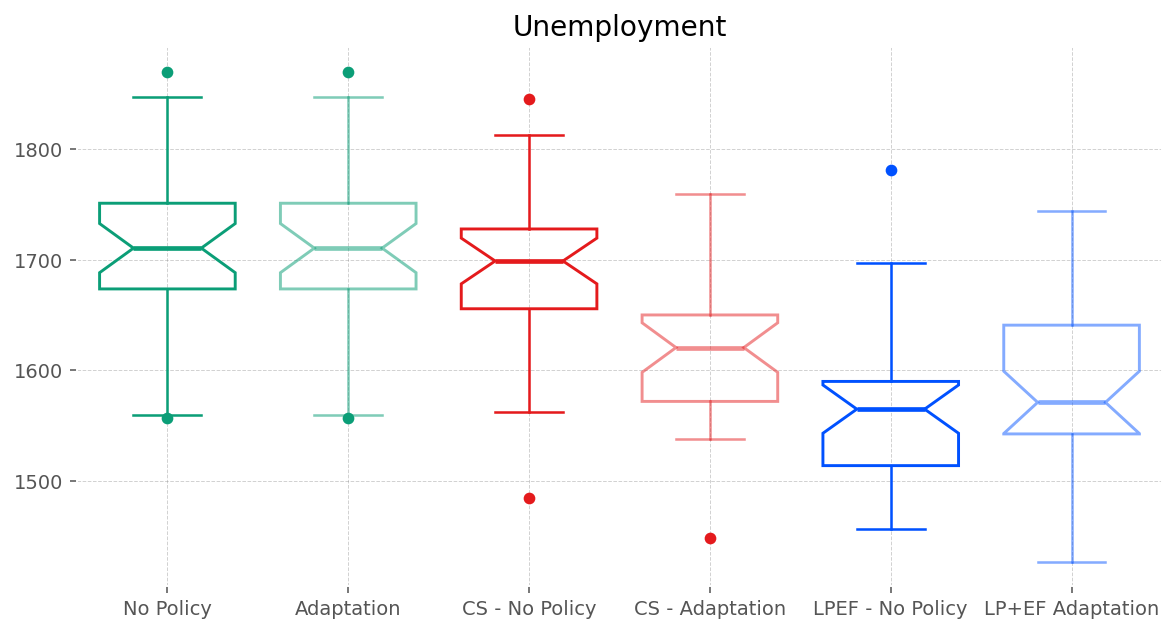

In [47]:
Unemployment = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    Unemployment[scenario] = temp_df.groupby(['run'])['Unemployment'].sum()
        

plot_boxplots(
    metric=Unemployment,
    scenario_names=scenario_names,
    labels=labels,
    colors=["#0B9E77","#0B9E7786", 
            "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"
            ],
    figsize=(10, 5),
    title="Unemployment",
    y_label='',
    save_path=OUTPUT / "Unemployment_box.pdf",
)

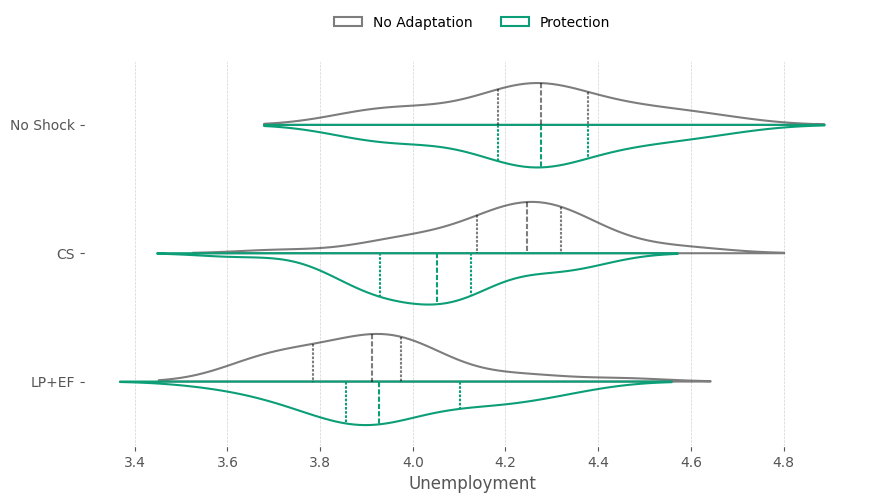

In [48]:
plot_split_violinplot(
    scenario_results,
    metric='Unemployment',
    metric_label='Unemployment',
    region='macro',
    tmin=200,
    palette={"No Adaptation": "#00000082", "Protection": "#0B9E77"}
)

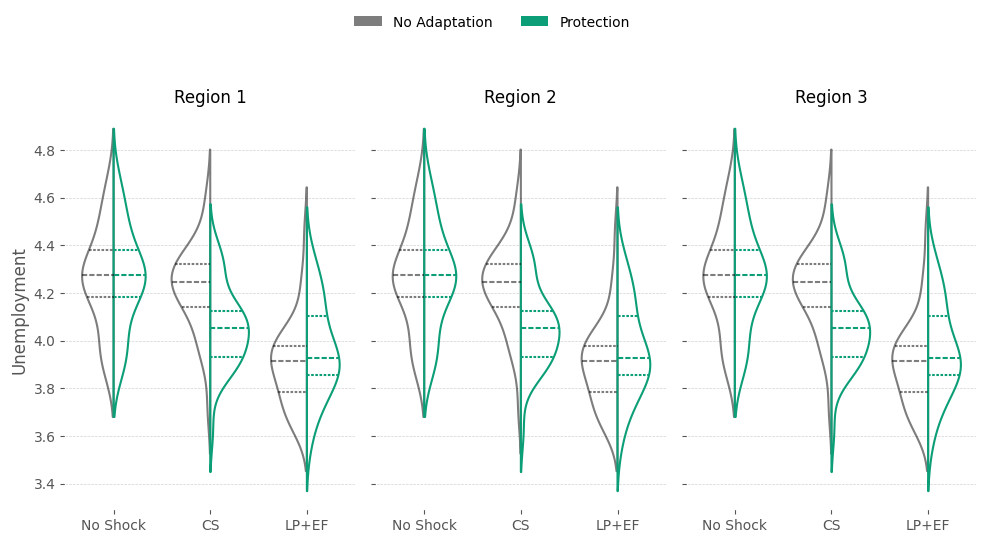

In [58]:
plot_regional_split_violin(
    metric="Unemployment",
    metric_label="Unemployment",
    tmin=200,
    scenario_mapper={
        1: 'No Shock',
        2: 'CS',
        3: 'LP+EF'
    },
    palette={
        "No Adaptation": "#00000082",
        "Protection": "#0B9E77"
    }
)

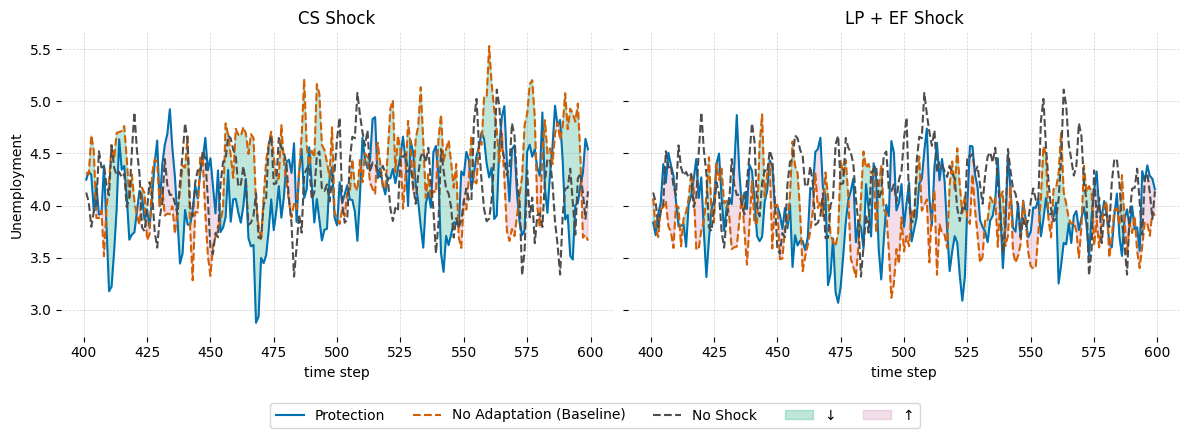

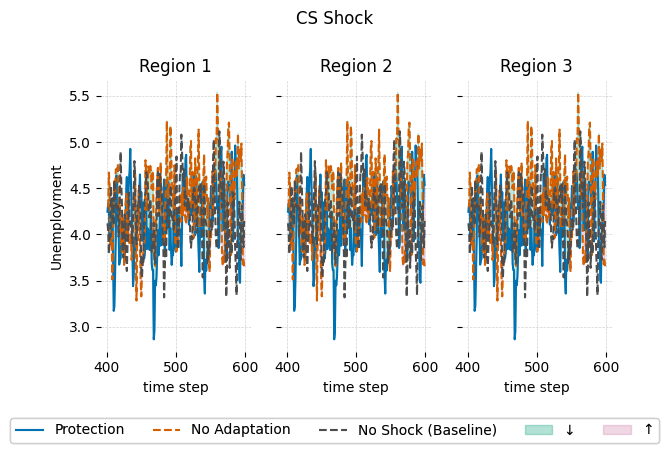

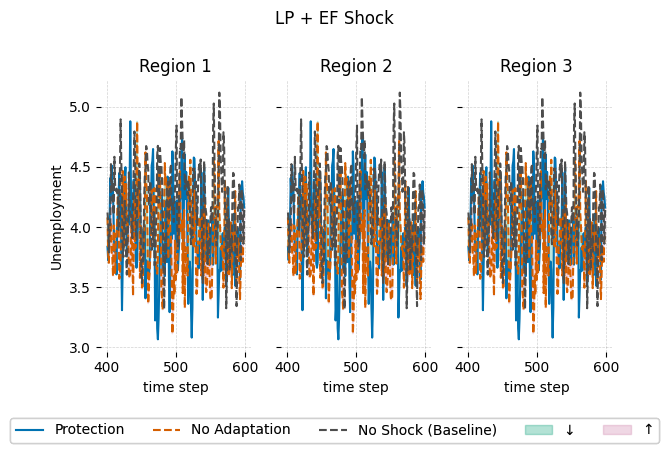

In [189]:
metric="Unemployment"
metric_label = 'Unemployment'
tmin = 400
tmax = 600
regions = ['macro']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True, dpi=100)
for idx, n in enumerate(['2', '3']):
    s0 = (
        scenario_results['No Adaptation_1']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s1 = (
        scenario_results[f'No Adaptation_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )
    s2 = (
        scenario_results[f'Protection_{n}']
        .loc[lambda df: df['region'].isin(regions)]
        .groupby('t')[metric]
        .mean()
        .reset_index()
        )

    s0.rename(columns={metric: 'No Shock'}, inplace=True)
    s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
    s2.rename(columns={metric: 'Protection'}, inplace=True)
    df = pd.merge(s1, s2, on='t')
    df = pd.merge(df, s0, on='t')
    df['t'] = df['t'].astype(int)
    df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

    ax = axes[idx]
    ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
    ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation (Baseline)")
    ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock")

    # Fill area where No Adaptation > Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
        interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
    )

    # Fill area where No Adaptation <= Protection
    ax.fill_between(
        df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
        interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
    )


    ax.set_xlabel('time step')
    if n == '2':
        ax.set_title("CS Shock")
    else:
        ax.set_title("LP + EF Shock")

# Only show legend on the first subplot
# place legend outside plot area below x-axis label
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    frameon=True
)
axes[0].set_ylabel(metric_label)
# turn off spineson both subplots
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

# add gridlinesto both subplots
for ax in axes:
    ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

plt.tight_layout()
plt.savefig(OUTPUT / f"{metric}_area_diff.pdf", bbox_inches='tight', dpi=300)
plt.show()


# metric="GDP_r_volatility"
# metric_label = 'GDP volatility'
# tmin = 300
# tmax = 600
for n in ['2', '3']:
    regions = [1, 2, 3]
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 4), sharey=True, dpi=100)
    for idx, region in enumerate(regions):

        s0 = (
            scenario_results['No Adaptation_1']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s1 = (
            scenario_results[f'No Adaptation_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )
        s2 = (
            scenario_results[f'Protection_{n}']
            .loc[lambda df: df['region'] == region]
            .groupby('t')[metric]
            .mean()
            .reset_index()
            )

        s0.rename(columns={metric: 'No Shock'}, inplace=True)
        s1.rename(columns={metric: 'No Adaptation'}, inplace=True)
        s2.rename(columns={metric: 'Protection'}, inplace=True)
        df = pd.merge(s1, s2, on='t')
        df = pd.merge(df, s0, on='t')
        df['t'] = df['t'].astype(int)
        df = df[(df['t'] > tmin) & (df['t'] < tmax)].copy()

        ax = axes[idx]
        ax.plot(df['t'], df['Protection'], color="#0072B2", label="Protection")
        ax.plot(df['t'], df['No Adaptation'], color="#D55E00", linestyle='--', label="No Adaptation")
        ax.plot(df['t'], df['No Shock'], color="#4D4D4D", linestyle='--', label="No Shock (Baseline)")

        # Fill area where No Adaptation > Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] > df['Protection']),
            interpolate=True, color="#009E73", alpha=0.25, label="↓" if idx == 0 else None
        )

        # Fill area where No Adaptation <= Protection
        ax.fill_between(
            df['t'], df['No Adaptation'], df['Protection'], where=(df['No Adaptation'] <= df['Protection']),
            interpolate=True, color="#CC79A7", alpha=0.25, label="↑" if idx == 0 else None
        )


        ax.set_xlabel('time step')

        ax.set_title(f"Region {region}")


        # Only show legend on the first subplot
        # place legend outside plot area below x-axis label
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.1),
        ncol=5,
        frameon=True
    )
    axes[0].set_ylabel(metric_label)
    # turn off spineson both subplots
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    # add gridlinesto both subplots
    for ax in axes:
        ax.grid(True, axis='both', alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='major') 

    # set figure title based on shock type
    if n == '2':
        fig.suptitle("CS Shock", y=1)
    elif n == '3':
        fig.suptitle("LP + EF Shock", y=1)

    plt.tight_layout()
    plt.savefig(OUTPUT / f"{metric}_area_diff_region_scenario{n}.pdf", bbox_inches='tight', dpi=300)
    plt.show()

### Sectoral net worth as % of nominal GDP

In [ ]:
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_h",
    metric_label='Networth of Households',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of Households',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    ymin=0, ymax=25000000,
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_h_line.pdf",
)

fig1

In [ ]:
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_1",
    metric_label='Networth of K-Firms',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of K-Firms',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    ymin=0, ymax=1500000,
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_1_line.pdf",
)


fig1

In [ ]:
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_gov_over_GDPn",
    metric_label='Networth of Central Government / GDP',
    snap_ts=np.arange(200, 620, 20),
    title='',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    # ymin=-0.25, ymax=-0.14,
        pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_gov_over_GDP_line.pdf",
)

fig1

In [ ]:

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_2",
    metric_label='Networth of C-Firms',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of C-Firms',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
        pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_2_line.pdf",
    # ymin=12.8, ymax=14
)

fig1

In [60]:
BG_COLOR = "white"  # use "rgba(0,0,0,0)" for transparent
GRID_COLOR = "rgba(128, 128, 128, 0.5)"

mean_sectoral_net_worth = {}
sectoral_net_worth = {}
sector_order = ["K-Firms", "C-Firms", "Households", "Banks", "Energy", "Govt."]

for scenario in ["No Adaptation_1", "Protection_1", ]:
    temp_df = scenario_results[scenario][scenario_results[scenario]["region"] == "macro"].copy()
    temp_df = temp_df[temp_df["t"] > 200].copy()
    for column in ["NW_1", "NW_2", "NW_h"]:
        temp_df[f"{column}_over_GDPn"] = temp_df[column] / (temp_df["GDP_n"] * 4)
    columns_dict = dict(
        zip(
            [
                "NW_1_over_GDPn",
                "NW_2_over_GDPn",
                "NW_h_over_GDPn",
                "NW_b_over_GDPn",
                "NW_e_over_GDPn",
                "NW_gov_over_GDPn",
            ],
            sector_order,
        )
    )
    temp_df.rename(columns=columns_dict, inplace=True)
    sectoral_net_worth[scenario] = temp_df

# ["dsk_sfc_2", "dsk_sfc_3", "hrhs_2", "hrhs_3"]
# for scenario in ["hrhs_3", ]:
#     net_worth = {}
#     for sector in sector_order:
#         if scenario.startswith("dsk"):
#             baseline = "dsk_sfc_1"
#         elif scenario.startswith("hrhs"):
#             baseline = "hrhs_1"

#         scenario_pairs = sectoral_net_worth[scenario][["t", "run", sector]].rename(
#             columns={sector: "scenario_val"}
#         )
#         baseline_pairs = sectoral_net_worth[baseline][["t", "run", sector]].rename(
#             columns={sector: "baseline_val"}
#         )

#         paired = scenario_pairs.merge(baseline_pairs, on=["t", "run"], how="inner")
#         paired["diff"] = (paired["scenario_val"] - paired["baseline_val"]) * 100

#         diff_by_t = paired.groupby("t")["diff"]
#         mean_diff = diff_by_t.mean()
#         n = diff_by_t.count().replace(0, np.nan)
#         std_diff = diff_by_t.std(ddof=1)
#         se_diff = std_diff / np.sqrt(n)
#         ci95 = 1.96 * se_diff

#         net_worth[sector] = {
#             "mean": mean_diff,
#             "ci95": ci95,
#         }
#     mean_sectoral_net_worth[scenario] = net_worth


color_dict = dict(
    zip(
        sector_order,
        [
            dict(color="rgb(219, 161, 55)"),
            dict(color="rgb(110, 177, 228)"),
            dict(color="rgb(19, 155, 116)"),
            dict(color="rgb(238, 227, 97)"),
            dict(color="rgb(69, 155, 116)"),
            dict(color="rgb(48, 111, 173)"),
        ],
    )
)

for scenario in mean_sectoral_net_worth.keys():
    fig = go.Figure()
    ci_trace_indices = []

    # 1) Add all sector mean lines first (legend row 1)
    for sector in sector_order:
        mean_series = mean_sectoral_net_worth[scenario][sector]["mean"]
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=mean_series.values,
                mode="lines",
                name=sector,
                line=color_dict[sector],
                legendgroup=f"line_{sector}",
                showlegend=True,
            )
        )

    # 2) Add all confidence bands second (legend row 2)
    for sector in sector_order:
        line_color = color_dict[sector]["color"]
        fill_color = line_color.replace("rgb(", "rgba(").replace(")", ", 0.25)")

        mean_series = mean_sectoral_net_worth[scenario][sector]["mean"]
        ci_series = mean_sectoral_net_worth[scenario][sector]["ci95"].reindex(mean_series.index).fillna(0)
        upper = mean_series + ci_series
        lower = mean_series - ci_series

        ci_group = f"ci_{sector}"

        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=upper.values,
                mode="lines",
                line=dict(width=0),
                legendgroup=ci_group,
                showlegend=False,
                hoverinfo="skip",
            )
        )

        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=lower.values,
                mode="lines",
                line=dict(width=0),
                fill="tonexty",
                fillcolor=fill_color,
                legendgroup=ci_group,
                name="(95% CI)",
                showlegend=True,
                hoverinfo="skip",
            )
        )
        # fig.update_yaxes(range=[-4, 4])

    fig.update_layout(
        plot_bgcolor=BG_COLOR,
        paper_bgcolor=BG_COLOR,
        width=1200,
        height=500,
        xaxis=dict(
            showgrid=True,
            gridcolor=GRID_COLOR,
            zeroline=True,
            zerolinecolor=GRID_COLOR,
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor=GRID_COLOR,
            zeroline=True,
            zerolinecolor=GRID_COLOR,
        ),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.20,
            xanchor="center",
            x=0.5,
            traceorder="normal",
            groupclick="togglegroup",
            entrywidthmode="fraction",
            entrywidth=0.16,
            tracegroupgap=0,
        ),
        margin=dict(b=150),
        )

    fig.show()

### Emissions

In [61]:
Emiss_TOT = pd.DataFrame()
for scenario in ['No Adaptation_2', 'No Adaptation_3', 'Protection_2', 'Protection_3']:
    if scenario.startswith('No Adaptation'):
        baseline = 'No Adaptation_1'
    elif scenario.startswith('Protection'):
        baseline = 'Protection_1'
    Emiss_TOT[scenario] =  (scenario_results[scenario].groupby('t')['Emiss_TOT'].mean() - (scenario_results[baseline].groupby('t')['Emiss_TOT'].mean())) / scenario_results[baseline].groupby('t')['Emiss_TOT'].mean() * 100

In [62]:
def build_emissions_change_figure(
    scenario_results,
    scenarios,
    baseline,
    line_colors,
    band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
):
    fig = go.Figure()

    for scenario in scenarios:
        sc_df = scenario_results[scenario].loc[
            scenario_results[scenario]['region'] == 'macro', ['t', 'run', 'Emiss_TOT']
        ]
        bl_df = scenario_results[baseline].loc[
            scenario_results[baseline]['region'] == 'macro', ['t', 'run', 'Emiss_TOT']
        ]

        paired = sc_df.merge(bl_df, on=['t', 'run'], suffixes=('_sc', '_bl'))
        paired['diff_pct'] = (
            (paired['Emiss_TOT_bl'] - paired['Emiss_TOT_sc'])
            / paired['Emiss_TOT_sc'].abs()
            * 100
        )
        paired = paired[paired['t'] > t_min]

        diff_by_t = paired.groupby('t')['diff_pct']
        mean_diff = diff_by_t.mean()
        n = diff_by_t.count().replace(0, np.nan)
        std_diff = diff_by_t.std(ddof=1)
        ci95 = 1.96 * std_diff / np.sqrt(n)

        x = mean_diff.index.to_numpy()
        upper = (mean_diff + ci95).to_numpy()
        lower = (mean_diff - ci95).to_numpy()

        if scenario.endswith('2'):
            name = 'CS'
        elif scenario.endswith('3'):
            name = 'LP+EF'
        fig.add_trace(go.Scatter(
            x=x,
            y=mean_diff.to_numpy(),
            mode='lines',
            name=name,
            line=dict(color=line_colors[scenario], width=2),
        ))

        fig.add_trace(go.Scatter(
            x=np.concatenate([x, x[::-1]]),
            y=np.concatenate([upper, lower[::-1]]),
            fill='toself',
            fillcolor=band_colors[scenario],
            line=dict(width=0),
            hoverinfo='skip',
            showlegend=False,
            name=f'{scenario} 95% CI',
        ))

    # fig.update_yaxes(range=[-10, 10], )

    fig.update_layout(
        width=800,
        height=500,
        title=title,
        xaxis_title='Timestep (t)',
        yaxis_title='Δ Emiss_TOT (%)',
        hovermode='x',
        plot_bgcolor=BG_COLOR,
        paper_bgcolor=BG_COLOR,
        xaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=True, zerolinecolor=GRID_COLOR),
        yaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=True, zerolinecolor=GRID_COLOR),
        template='simple_white',
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=-0.2,
            yanchor='top',
        ),
        margin=dict(b=90),
    )

    return fig



In [63]:
line_colors = {
    'No Adaptation_2': 'rgb(220, 38, 38)',
    'No Adaptation_3': 'rgb(37, 99, 235)',
}
band_colors = {
    'No Adaptation_2': 'rgba(220, 38, 38, 0.2)',
    'No Adaptation_3': 'rgba(37, 99, 235, 0.2)',
}

fig = build_emissions_change_figure(
    scenario_results=scenario_results,
    scenarios=['No Adaptation_2', 'No Adaptation_3'],
    baseline='No Adaptation_1',
    line_colors=line_colors,
    band_colors=band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
)

fig.write_image(OUTPUT / f"Emissions_small_more_exposed.pdf", scale=1)
fig.show()

In [64]:
line_colors = {
    'Protection_2': 'rgb(220, 38, 38)',
    'Protection_3': 'rgb(37, 99, 235)',
}
band_colors = {
    'Protection_2': 'rgba(220, 38, 38, 0.2)',
    'Protection_3': 'rgba(37, 99, 235, 0.2)',
}

fig = build_emissions_change_figure(
    scenario_results=scenario_results,
    scenarios=['Protection_2', 'Protection_3'],
    baseline='Protection_1',
    line_colors=line_colors,
    band_colors=band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
)

fig.write_image(OUTPUT / f"Emissions_large_more_exposed.pdf", scale=1)
fig.show()

## Regional consistency

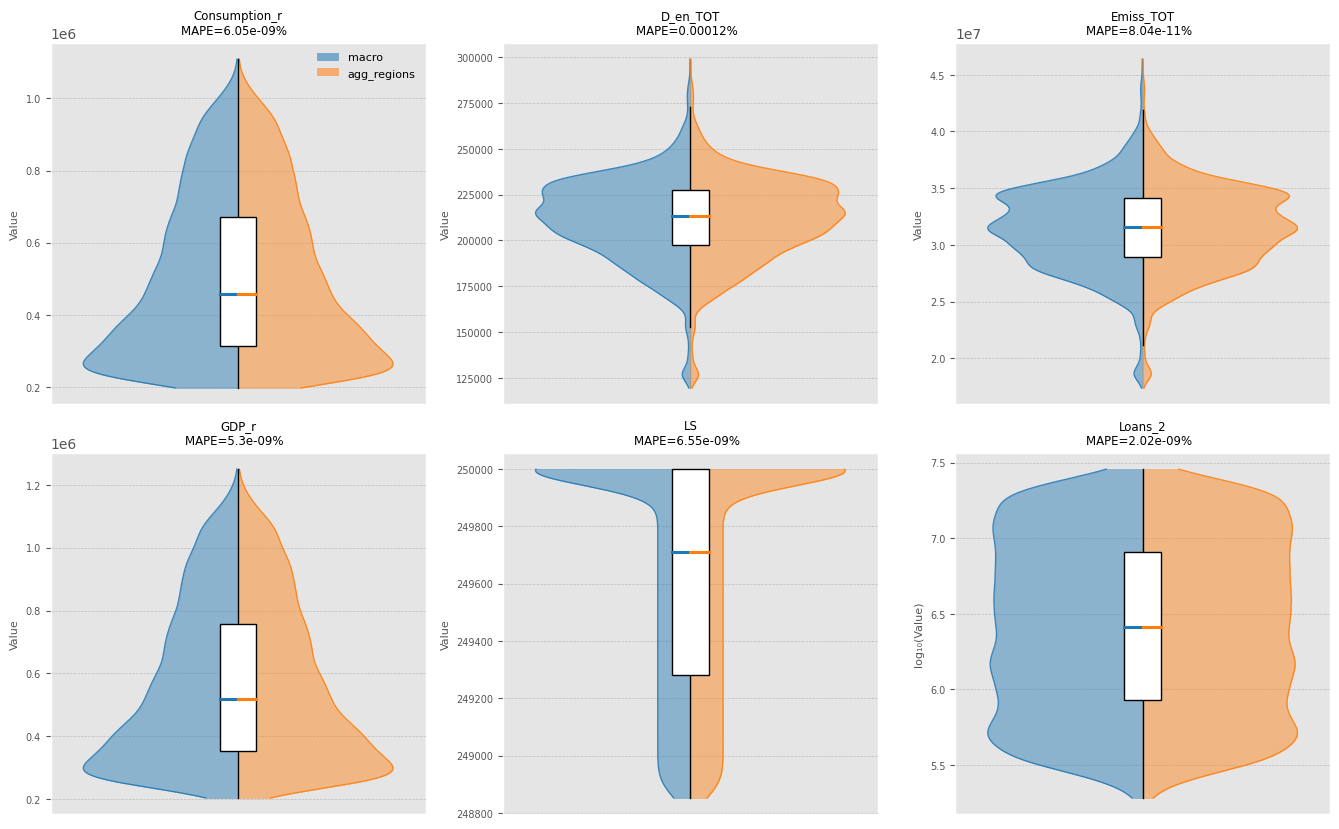

        variable  n_obs     mean_bias       mae      rmse  mean_abs_pct_err  \
0  Consumption_r  18000 -1.012651e-07  0.000025  0.000029      6.050014e-09   
1       D_en_TOT  18000 -3.562237e-03  0.249760  0.288428      1.197354e-04   
2      Emiss_TOT  18000  1.501573e-07  0.000025  0.000029      8.041851e-11   
3          GDP_r  18000  8.103185e-08  0.000025  0.000029      5.299633e-09   
4             LS  18000 -1.011100e-06  0.000016  0.000023      6.550947e-09   
5        Loans_2  18000  1.705771e-07  0.000025  0.000029      2.024129e-09   

   max_abs_pct_err  corr  welch_t_pvalue  cohens_d     ks_pvalue  close_ratio  \
0     2.522111e-08   1.0        1.000000 -0.003496  1.000000e+00          1.0   
1     4.012580e-04   1.0        0.999988 -0.012351  1.000000e+00          1.0   
2     2.739490e-10   1.0        1.000000  0.005210  1.000000e+00          1.0   
3     2.359313e-08   1.0        1.000000  0.002824  1.000000e+00          1.0   
4     2.002168e-08   1.0        1.000000 

In [65]:


check_regional_consistency(
    scenario_results['Protection_1'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'LS', 
    'Emiss_TOT',
    'Consumption_r',
    'Loans_2', 'D_en_TOT'],
    },
    output = OUTPUT / "regional_consistency_NoShock.pdf"
)

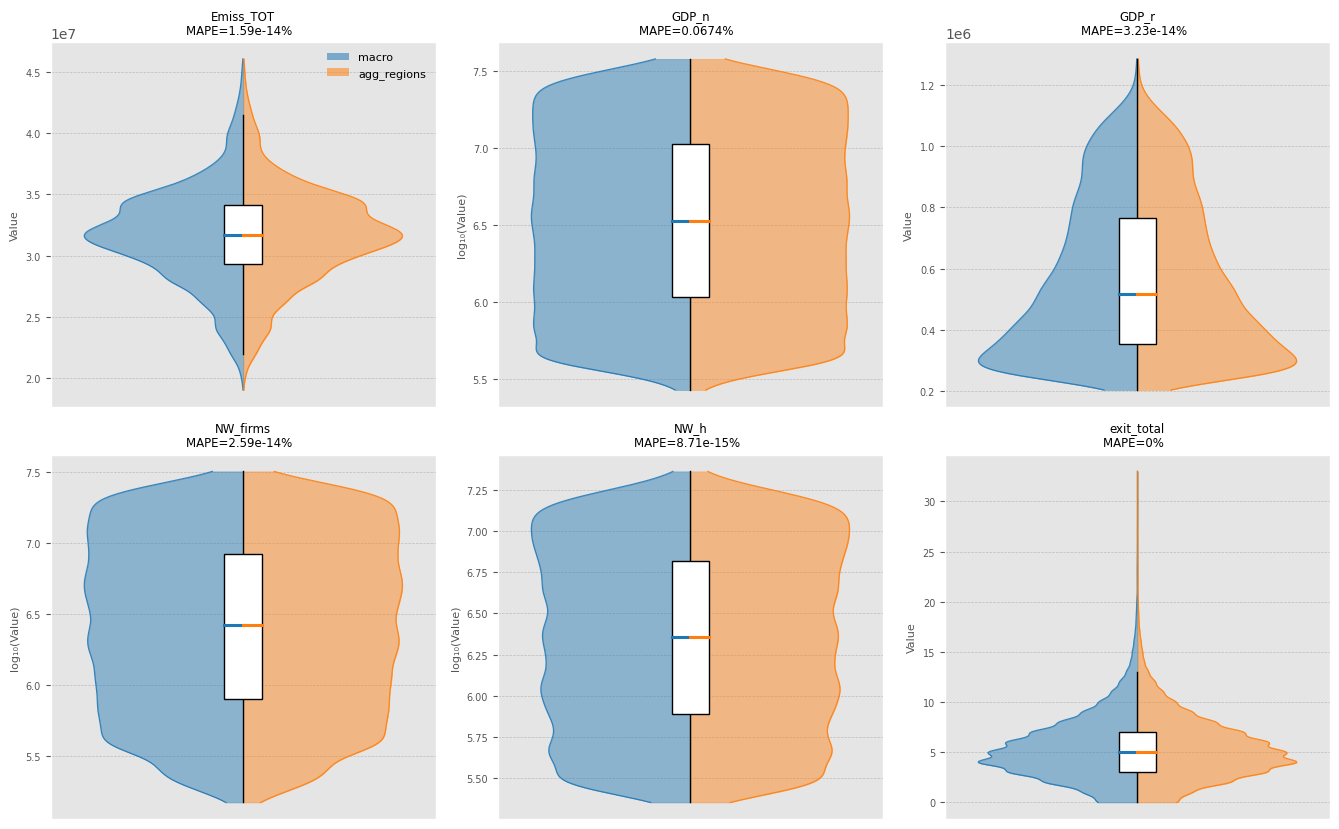

     variable  n_obs     mean_bias           mae          rmse  \
0   Emiss_TOT  18000 -1.065847e-10  5.017759e-09  6.774898e-09   
1       GDP_n  18000 -5.346858e+03  5.346858e+03  9.689566e+03   
2       GDP_r  18000  1.117264e-12  1.780039e-10  2.432682e-10   
3    NW_firms  18000  4.718701e-11  1.364785e-09  2.677133e-09   
4        NW_h  18000  4.592099e-11  3.367847e-10  7.695522e-10   
5  exit_total  18000  0.000000e+00  0.000000e+00  0.000000e+00   

   mean_abs_pct_err  max_abs_pct_err  corr  welch_t_pvalue  cohens_d  \
0      1.590051e-14     1.243463e-13   1.0        1.000000 -0.015734   
1      6.744747e-02     3.373465e-01   1.0        0.950438 -0.661659   
2      3.229269e-14     3.299408e-13   1.0        1.000000  0.004593   
3      2.594939e-14     1.627459e-13   1.0        1.000000  0.017628   
4      8.711999e-15     7.830468e-14   1.0        1.000000  0.059777   
5      0.000000e+00     0.000000e+00   1.0        1.000000  0.000000   

   ks_pvalue  close_ratio  passe

In [66]:
check_regional_consistency(
    scenario_results['Protection_2'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'exit_total', 'GDP_n',
    'Emiss_TOT', 'NW_firms', 'NW_h']},
    output = OUTPUT / "regional_consistency_CS.pdf"
)

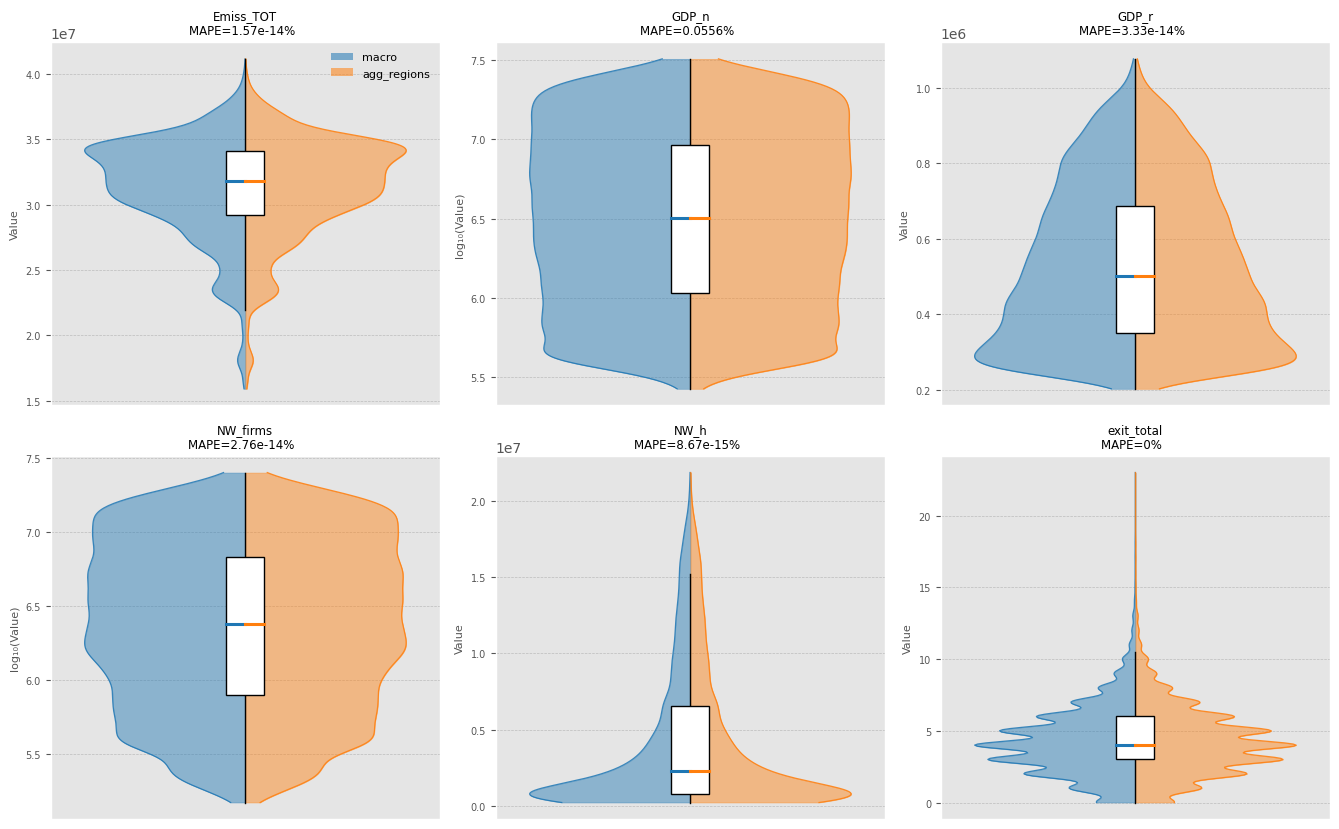

     variable  n_obs     mean_bias           mae          rmse  \
0   Emiss_TOT  18000 -1.470455e-10  4.883338e-09  6.617169e-09   
1       GDP_n  18000 -3.403107e+03  3.403107e+03  5.903704e+03   
2       GDP_r  18000 -5.448884e-13  1.744403e-10  2.384633e-10   
3    NW_firms  18000  3.004324e-11  1.243068e-09  2.368685e-09   
4        NW_h  18000  4.908361e-11  3.373700e-10  7.801737e-10   
5  exit_total  18000  0.000000e+00  0.000000e+00  0.000000e+00   

   mean_abs_pct_err  max_abs_pct_err  corr  welch_t_pvalue  cohens_d  \
0      1.567287e-14     1.243463e-13   1.0        1.000000 -0.022227   
1      5.561233e-02     3.373465e-01   1.0        0.962352 -0.705410   
2      3.331463e-14     3.299408e-13   1.0        1.000000 -0.002285   
3      2.763503e-14     1.627459e-13   1.0        1.000000  0.012684   
4      8.672326e-15     7.830468e-14   1.0        1.000000  0.063037   
5      0.000000e+00     0.000000e+00   1.0        1.000000  0.000000   

   ks_pvalue  close_ratio  passe

In [67]:
check_regional_consistency(
    scenario_results['Protection_3'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'exit_total', 'GDP_n',
    'Emiss_TOT', 'NW_firms', 'NW_h']},
    output = OUTPUT / "regional_consistency_LPEF.pdf"
)